# Brain tumour grading generative model

### Load libraries

In [3]:
%cd /g/data/hl36/mhf/monai/Task03_BrainTumourDx
# torch imports
import torch
from torch import nn
import torch.nn.functional as F
from torch.nn import L1Loss
from torch.cuda.amp import GradScaler, autocast

# python imports

from datetime import datetime
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import copy
from collections import OrderedDict

# monai imports
from generative.networks.nets import AutoencoderKL, PatchDiscriminator, DiffusionModelUNet
from generative.networks.schedulers import DDIMScheduler
from generative.inferers import DiffusionInferer
from generative.losses import PatchAdversarialLoss, PerceptualLoss
from monai.networks.layers import Act
from monai import transforms
from monai.data.dataset import CacheDataset
from monai.config import print_config
from monai.data import DataLoader
from monai.utils import set_determinism, first
from monai.inferers import sliding_window_inference

/g/data/hl36/mhf/monai/Task03_BrainTumourDx


/scratch/hl36/nk9793/venv/monai_res3/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


### Load data

#### Define training and validation sets

In [4]:
import json, os
import csv
from pathlib import Path
nnunet_project_root = Path('/scratch/hl36/mhf/nnunet/raw/Dataset004_T1T1cT2FLAIRGrade').resolve()
train_dir = Path(nnunet_project_root, 'imagesTr').resolve()
label_dir = Path(nnunet_project_root, 'labelsTr').resolve()

dataroot = Path('/g/data/hl36/mhf/monai/Task03_BrainTumourDx').resolve()

ages = []
data_dict = {}
subjs = []
csv_file_path = Path("/g/data/hl36/mhf/monai/Task03_BrainTumourDx/2025_cancer_dataset_v2.csv").resolve()  # Replace with the actual path to your CSV file
with open(csv_file_path, mode='r') as file:
    csv_reader = csv.DictReader(file)
    
    # Iterate through the rows and extract relevant information
    for row in csv_reader:
        data_id = row['DataID']
        if data_id == 'nnUNetv2-00643':
            break
        #sex = row['Sex']
        #age = float(row['Age'])
        #grade = int(row["WHOGrade"])
        dx = row['Dx']
        img_path = f"imagesTr/{data_id}_0002.nii.gz"
        if 'Glioblastoma' in dx:
            dx = 'GBM' if np.random.random_sample() >= 0.5 else "glioblastoma"
        elif 'Oligodendroglioma' in dx:
            dx = 'oligodendroglioma' if np.random.random_sample() >= 0.5 else "oligo"
        elif 'Astrocytoma' in dx:
            dx = 'astro' if np.random.random_sample() >= 0.5 else "astrocytoma"
        elif 'Healthy' in dx:
            dx = 'no abnormalities' if np.random.random_sample() >= 0.5 else 'nil finding'
        #OS = int(row['OS'])
        #MGMT = row['MGMT status']
        #MGMT_index = row['MGMT_index']
        #surv = row['vital_status']
        #eor = row['EOR']
        
        
        subjs.append(data_id)
        #ages.append(age)
        
        # Add the extracted data to the dictionary, keyed by DataID
        data_dict[data_id] = {'Dx': dx, 'img_path': img_path}
        #data_dict[data_id] = {'Sex': sex, 'Age': age, 'Dx': dx, 'grade': grade, 'OS': OS, 'MGMT_status': MGMT, 'MGMT_index': MGMT_index, 'vital_status': surv, 'EOR': eor, 'FLAIR_path': img_path}

In [3]:
data_dict_file = './data_dictionary_clinical_T2_includingHCP.json'
with open(data_dict_file, "w", encoding="utf-8") as f:
    json.dump(data_dict, f, ensure_ascii=True, indent=4)
print(f"Datalist is saved to {data_dict_file}")

Datalist is saved to ./data_dictionary_clinical_T2_includingHCP.json


In [5]:
import nibabel as nib
import subprocess
import random
import copy

split = 0.8
random.seed(42)
random.shuffle(subjs)
subjs_tr = subjs[:int(len(subjs)*split)]
subjs_val = subjs[int(len(subjs)*split):]
print(subjs_tr[:10])
print(subjs_val[:10])

['129634', 'nnUNetv2-00174', 'nnUNetv2-00218', 'nnUNetv2-00403', 'nnUNetv2-00585', 'nnUNetv2-00535', 'nnUNetv2-00064', '735148', '622236', 'nnUNetv2-00232']
['nnUNetv2-00455', 'nnUNetv2-00458', '101309', 'nnUNetv2-00557', '300618', 'nnUNetv2-00164', 'nnUNetv2-00576', 'nnUNetv2-00641', 'nnUNetv2-00600', 'nnUNetv2-00375']


In [6]:
import nibabel as nib
import numpy as np
from nibabel.orientations import aff2axcodes, axcodes2ornt, ornt_transform, apply_orientation
from scipy.ndimage import generate_binary_structure, label as cc_label, convolve

# ---------- utils: LPS loader & volumes ----------
def load_nifti_LPS(path):
    img = nib.load(path)
    arr = img.get_fdata()
    codes = aff2axcodes(img.affine)
    if tuple(codes) != ('L','P','S'):
        orig = axcodes2ornt(codes)
        targ = axcodes2ornt(('L','P','S'))
        xform = ornt_transform(orig, targ)
        arr = apply_orientation(arr, xform)
        # reorder voxel sizes to match new axes
        z = img.header.get_zooms()[:3]
        order = xform[:, 0].astype(int)
        vox = tuple(z[i] for i in order)
    else:
        vox = img.header.get_zooms()[:3]
    return arr, vox  # arr shape (X,Y,Z) in LPS; vox = (vx,vy,vz) mm

def voxel_volume_ml(vox):  # mm^3 -> mL
    vx, vy, vz = map(float, vox)
    return (vx * vy * vz) / 1000.0

# ---------- enhancement / necrosis helpers ----------
def has_label(lab, label_id): return bool((lab == label_id).any())

def has_central_necrosis(lab, core_label=1, min_core_ml=5.0, vox=None):
    if vox is None: return has_label(lab, core_label)
    vol_ml = (lab == core_label).sum() * voxel_volume_ml(vox)
    return vol_ml >= float(min_core_ml)

# ---- RING ENHANCEMENT (ET surrounds core)
def detect_ring_enhancement(label_path, core_label=1, enh_label=3, shell_radius_vox=3, inner_clear_vox=1, min_ring_frac=0.30, min_touch_frac=0.50):
    lab, _ = load_nifti_LPS(label_path)
    core = (lab == core_label)
    enh  = (lab == enh_label)
    if not enh.any():  # no enhancing component
        return False, 0.0, 0.0

    # 3D morphology via convolution (structuring element cube)
    ksize = 2*shell_radius_vox + 1
    K = np.ones((ksize, ksize, ksize), dtype=np.uint8)

    # dilation/erosion (binary via conv thresholds)
    dil_core = convolve(core.astype(np.uint8), K, mode="constant", cval=0) > 0
    if inner_clear_vox > 0:
        kin = 2*inner_clear_vox + 1
        Kin = np.ones((kin, kin, kin), dtype=np.uint8)
        ero_core = convolve(core.astype(np.uint8), Kin, mode="constant", cval=0) == Kin.size
    else:
        ero_core = core

    shell = dil_core & (~ero_core)  # ring zone around core
    if shell.sum() == 0:
        return False, 0.0, 0.0

    enh_in_shell = (enh & shell).sum()
    ring_frac_shell = float(enh_in_shell) / float(shell.sum())       # how much of shell is enhancing
    # also require most ET to be near core
    enh_touch_core = (enh & dil_core).sum()
    touch_frac = float(enh_touch_core) / float(enh.sum())

    is_ring = (ring_frac_shell >= min_ring_frac) and (touch_frac >= min_touch_frac)
    return bool(is_ring), float(ring_frac_shell), float(touch_frac)

# ---------- edema severity (label 2) ----------
def edema_severity_from_labels(label_path, edema_label=2, brain_volume_ml=None):
    lab, vox = load_nifti_LPS(label_path)
    ed_vox = int((lab == edema_label).sum())
    ed_ml  = ed_vox * voxel_volume_ml(vox)

    # If you have brain volume, use fractions; else absolute ml thresholds.
    if brain_volume_ml is not None and brain_volume_ml > 0:
        frac = ed_ml / brain_volume_ml
        if   frac >= 0.20: sev = "severe"
        elif frac >= 0.10: sev = "moderate"
        elif frac >= 0.03: sev = "mild"
        else:              sev = "none"
        return sev, ed_ml, frac
    else:
        # Absolute ml heuristic (tune to cohort)
        if   ed_ml >= 100.0: sev = "severe"
        elif ed_ml >= 50.0:  sev = "moderate"
        elif ed_ml >= 20.0:  sev = "mild"
        else:                sev = "none"
        return sev, ed_ml, None

# Optional: rough brain volume estimate (if no brain mask) from T2/FLAIR by simple threshold
def estimate_brain_vol(image_path, lower_pct=15, upper_pct=99):
    img, vox = load_nifti_LPS(image_path)
    prc = np.percentile(img, [lower_pct, upper_pct])
    brain = (img > prc[0]) & (img < prc[1])  # crude intracranial proxy
    return brain.sum() * voxel_volume_ml(vox)

# ---------- mass effect severity (uses MLS + lesion volume) ----------
def lesion_volume_ml_from_labels(label_path, lesion_labels=(1,2,4)):
    lab, vox = load_nifti_LPS(label_path)
    lesion = np.isin(lab, lesion_labels)
    return lesion.sum() * voxel_volume_ml(vox)

def mass_effect_severity(mls_mm: float, lesion_ml: float):
    # Heuristic bins; adjust to your cohort/radiologist feedback
    if (mls_mm >= 10.0) or (lesion_ml >= 120.0 and mls_mm >= 5.0):
        return "severe"
    if (5.0 <= mls_mm < 10.0) or (lesion_ml >= 70.0):
        return "moderate"
    if (3.0 <= mls_mm < 5.0) or (lesion_ml >= 30.0):
        return "mild"
    return "none"

# ---------- location (reuse your fixed version) ----------
def location_from_label_LPS(label_path, nonenh_label=1, enh_label=3, bilateral_frac=0.10, midline_mm=5.0, vx_vol_ml=1.0):
    lab, vox = load_nifti_LPS(label_path)
    mask = (lab == enh_label) & (lab == nonenh_label)
    if not mask.any():
        tumour = lab == 3 # use edema instead
        if not tumour.any(): return None, None, None
        mask = tumour

    # --- multiple lesion check ---
    struct24 = generate_binary_structure(rank=3, connectivity=3)  # 3D, includes faces+edges+corners
    cc, num = cc_label(mask, structure=struct24)
    lesion_vols = [(cc == i).sum() * vx_vol_ml for i in range(1, num + 1)]
    total_vol_ml = sum(lesion_vols)

    if num > 1:
        lesion_text = f"{num} separate lesions totalling {total_vol_ml:.1f} mL"
    else:
        lesion_text = f"a lesion measuring {total_vol_ml:.1f} mL"
        
    X, Y, Z = mask.shape
    x_mid = (X - 1) / 2.0
    left_vox  = mask[int(np.floor(x_mid))+1:, :, :].sum()
    right_vox = mask[:int(np.ceil(x_mid)),  :, :].sum()
    vox_total = mask.sum()
    lf = float(left_vox) / float(vox_total); rf = float(right_vox) / float(vox_total)
    idxs = np.argwhere(mask); com = idxs.mean(0)
    x_dist_mm = abs(com[0] - x_mid) * float(voxel_volume_ml((vox[0],1,1)) * 1000)  # simplify to use vx; next line cleaner:
    x_dist_mm = abs(com[0] - x_mid) * float(vox[0])
    if lf > bilateral_frac and rf > bilateral_frac: laterality = "bilateral"
    elif x_dist_mm <= midline_mm:                   laterality = "midline"
    else:                                           laterality = "left" if lf >= rf else "right"
    y_frac = float(com[1] / max(Y - 1, 1)); z_frac = float(com[2] / max(Z - 1, 1))
    if   y_frac <= 1/3:   lobe = "frontal"
    elif y_frac >= 2/3:   lobe = "occipital"
    else:                 lobe = "temporal" if z_frac < 0.45 else "parietal"
    if laterality == "bilateral": return f"in the bilateral {lobe} lobes", num, lesion_text
    if laterality == "midline":   return f"in the midline {lobe} region", num, lesion_text
    return f"in the {laterality} {lobe} lobe", num, lesion_text

# ---------- midline shift (reuse your symmetry-based estimator) ----------
def estimate_midline_shift_mm(image_path, label_path, tumour_label_any=(1,2,4), search_vox=15):
    img, vox = load_nifti_LPS(image_path)
    lab, _   = load_nifti_LPS(label_path)
    X, Y, Z = img.shape; vx = float(vox[0])
    tumour = np.isin(lab, tumour_label_any)
    if not tumour.any(): return 0.0, "none", None
    areas = tumour.sum(axis=(0,1)); z = int(np.argmax(areas))
    I = img[:, :, z].astype(np.float32)
    p1, p99 = np.percentile(I, [1, 99]); I = np.clip((I - p1) / (p99 - p1 + 1e-6), 0, 1)
    x_mid0 = (X - 1) / 2.0
    best_cc, best_cx = -1.0, x_mid0
    for cx in range(int(x_mid0 - search_vox), int(x_mid0 + search_vox) + 1):
        cx = int(np.clip(cx, 1, X-2))
        w = int(min(cx, X - cx)); 
        if w < 8: continue
        L = I[cx - w:cx, :]; R = I[cx:cx + w, :]
        Lf = L[::-1, :]
        L0 = Lf - Lf.mean(); R0 = R - R.mean()
        denom = (np.linalg.norm(L0) * np.linalg.norm(R0) + 1e-6)
        cc = float((L0 * R0).sum() / denom)
        if cc > best_cc: best_cc, best_cx = cc, cx
    delta_vox = best_cx - x_mid0
    mls_mm = abs(delta_vox) * vx
    direction = "leftward" if delta_vox > 0 else ("rightward" if delta_vox < 0 else "none")
    return float(mls_mm), direction, z

# ---------- prompt composer (template) ----------
def compose_prompt_T2_template(image_path, label_path, ring_enhanced: bool,
                               include_diag: str = ""):
    lab, vox = load_nifti_LPS(label_path)
    # 1) enhancement phrase
    enh = "no enhancement"
    if ring_enhanced: 
        # 2) ring-enhancement from labels (core=1, enhancing=4)
        is_ring, ring_frac_shell, touch_frac = detect_ring_enhancement(label_path, core_label=1, enh_label=3,
                                                                       shell_radius_vox=3, inner_clear_vox=1,
                                                                       min_ring_frac=0.30, min_touch_frac=0.50)
        if is_ring is True:
            enh = "ring enhancement"
        else:
            enh = "solid enhancement"
    # 2) necrosis
    nec = has_central_necrosis(lab, core_label=1, min_core_ml=5.0, vox=vox)
    # 3) edema severity
    brain_vol = estimate_brain_vol(image_path, lower_pct=0, upper_pct=100)
    ed_sev, ed_ml, ed_frac = edema_severity_from_labels(label_path, edema_label=2, brain_volume_ml=brain_vol)
    # 4) MLS + direction
    mls_mm, mls_dir, _ = estimate_midline_shift_mm(image_path, label_path, tumour_label_any=(1,2,3), search_vox=15)
    # 5) lesion volume + mass effect
    les_ml = lesion_volume_ml_from_labels(label_path, lesion_labels=(1,2,3))
    me_sev = mass_effect_severity(mls_mm, les_ml)
    # 6) location
    loc, cc, les_text = location_from_label_LPS(label_path, nonenh_label=1, bilateral_frac=0.10, midline_mm=5.0, vx_vol_ml=voxel_volume_ml(vox))

    # build parts
    parts = []
    parts.append("A T2 MRI with")
    if cc == 1:
        if les_ml >= 0.1 * brain_vol:
            parts.append("a large lesion")
        elif les_ml >= 0.05 * brain_vol:
            parts.append("a moderate lesion")
        else:
            parts.append("a small lesion")
    else:
        if les_text: parts.append(les_text)
    parts.append(enh)
    if nec: parts.append("central necrosis")
    if ed_sev != "none": parts.append(f"{ed_sev} FLAIR edema")
    if me_sev != "none": parts.append(f"{me_sev} mass effect")
    if (mls_mm >= 3.0) and (mls_dir != "none"): parts.append(f"{mls_mm:.0f} mm {mls_dir} midline shift")
    
    if loc: parts.append(loc)
    if include_diag: parts.append(include_diag)  # optional
    text = ", ".join(parts).replace("with, ", "with ")
    return text, {
        "enhancement": enh, "necrosis": bool(nec), "edema_ml": ed_ml, "edema_sev": ed_sev,
        "lesion_ml": les_ml, "mass_effect": me_sev, "mls_mm": mls_mm, "mls_dir": mls_dir, "location": loc
    }


### Set up dataset json

In [18]:
datalist_json = {
    "name": "BRATS",
    "modality": {
        0 : "T1", 
        1 : "T1c", 
        2 : "T2", 
        3 : "FLAIR"
    },
    "tensorImageSize": "4D",
    "labels": {
        0 : "background",
        1 : "edema",
        2 : "non-enhancing tumor",
        3 : "enhancing tumor"
    },
    "numTraining": len(subjs_tr),
    "numTest": len(subjs_val),
    "training": [], 
    "test": []
}

SURGERY = {
    "GTR": "gross total",
    "STR": "sub total",
    "biopsy": "biopsy",
}


import nibabel as nib
import numpy as np
from nibabel.orientations import aff2axcodes, axcodes2ornt, ornt_transform, apply_orientation

for i, subj in tqdm(enumerate(subjs_tr), total=len(subjs_tr)):
    full_file_name = str(dataroot) + '/imagesTr/' + subj + '_biascorr_mni1mm_0002.nii.gz'
    if 'nnUNet' in subj:
        label_file_name = str(dataroot) + '/labelsTr/' + subj + '.nii.gz'

    else:
        label_file_name = str(dataroot)+ "/labelsTr/" + subj + "_biascorr_mni1mm.nii.gz"

    base_text = 'a T2 MRI with ' + data_dict[subj]["Dx"]
    # don't append for healthy prompts
    if "normal" in base_text.lower() or "nil finding" in base_text.lower():
        final_text = base_text
    else:
        # if you already computed ring via your earlier function, pass it here; else quick proxy:
        lab_arr, _ = load_nifti_LPS(label_file_name)
        ring_guess = has_label(lab_arr, 3) and has_label(lab_arr, 1)  # ET + core present
        final_text, attr_dict = compose_prompt_T2_template(
        image_path=full_file_name,
        label_path=label_file_name,
        ring_enhanced=ring_guess,
        include_diag=""  # or e.g., data_dict[subj]["Dx"]
    )

    datalist_json["training"].append({
        "image": full_file_name,
        "label": label_file_name,
        "text":  final_text
    })
    #subj_files = [str(train_dir) + '/' + subj + '_' + "{:04d}".format(n) + '.nii.gz' for n in range(4)]
    #subj_file = str(train_dir) + '/' + subj + '_0003.nii.gz'
    #nib_objs = [nib.load(f) for f in subj_files]
    
    #full_img = nib.funcs.concat_images(nib_objs)
    #nib.save(full_img, full_file_name)
    #nnunet_label = str(label_dir) + '/' + subj + '.nii.gz'
    # if full_file_name.exists() is False:
    #     subprocess.check_output(['rsync', '-avPS', f'{subj_file}', f'{full_file_name}'])
    #surgery = SURGERY.get(data_dict[subj]['EOR'])
    

100%|██████████| 739/739 [38:25<00:00,  3.12s/it]


### now the testing set

In [20]:
datalist_json["test"] = []

In [21]:
for i, subj in tqdm(enumerate(subjs_val), total=len(subjs_val)):
    full_file_name = str(dataroot) + '/imagesTr/' + subj + '_biascorr_mni1mm_0002.nii.gz'
    if 'nnUNet' in subj:
        label_file_name = str(dataroot) + '/labelsTr/' + subj + '.nii.gz'

    else:
        label_file_name = str(dataroot)+ "/labelsTr/" + subj + "_biascorr_mni1mm.nii.gz"

    base_text = 'a T2 MRI with ' + data_dict[subj]["Dx"]
    # don't append for healthy prompts
    if "normal" in base_text.lower() or "nil finding" in base_text.lower():
        final_text = base_text
    else:
        # if you already computed ring via your earlier function, pass it here; else quick proxy:
        lab_arr, _ = load_nifti_LPS(label_file_name)
        ring_guess = has_label(lab_arr, 3) and has_label(lab_arr, 1)  # ET + core present
        final_text, attr_dict = compose_prompt_T2_template(
        image_path=full_file_name,
        label_path=label_file_name,
        ring_enhanced=ring_guess,
        include_diag=""  # or e.g., data_dict[subj]["Dx"]
    )

    datalist_json["test"].append({
        "image": full_file_name,
        "label": label_file_name,
        "text":  final_text
    })

100%|██████████| 185/185 [09:44<00:00,  3.16s/it]


In [22]:
# save
datalist_file = "/g/data/hl36/mhf/monai/Task03_BrainTumourDx/dataset_T2_includingHCP.json"
with open(datalist_file, "w", encoding="utf-8") as f:
    json.dump(datalist_json, f, ensure_ascii=True, indent=4)
print(f"Datalist is saved to {datalist_file}")

Datalist is saved to /g/data/hl36/mhf/monai/Task03_BrainTumourDx/dataset_T2_includingHCP.json


In [7]:
import json
datalist_file = "/g/data/hl36/mhf/monai/Task03_BrainTumourDx/dataset_T2_includingHCP.json"
with open(datalist_file, "r", encoding="utf-8") as f:
    datalist_json = json.load(f)
    

In [8]:
import numpy as np
import torch
from monai.config.type_definitions import NdarrayOrTensor
from monai.transforms.transform import Transform
from monai.utils.enums import TransformBackends
from monai.config import DtypeLike, KeysCollection
from monai.transforms.transform import MapTransform
from collections.abc import Callable, Hashable, Mapping

class ConvertToMultiChannelBasedOnBratsGliomaPosTreatClasses2024(Transform):
    """
    Convert labels to multi channels based on brats24 Glioma post treatment classes:

    label 1: NETC denotes necrosis and cysts within the tumor.
    label 2: SNFH includes edema, infiltrating tumor, and post-treatment changes.
    label 3: ET describes the regions of active tumor as well as nodular areas of enhancement.
    label 4: RC consists of both recent and chronic resection cavities and typically contains fluid, blood, air, and/or proteinaceous materials.
    Return:
        The possible classes TC (Tumor core), WT (Whole tumor), ET (Enhancing tumor) and RC (resection cavity).
    """

    backend = [TransformBackends.TORCH, TransformBackends.NUMPY]

    def __call__(self, img: NdarrayOrTensor) -> NdarrayOrTensor:
        # if img has channel dim, squeeze it
        if img.ndim == 4 and img.shape[0] == 1:
            img = img.squeeze(0)

        result = [(img == 1) | (img == 3), (img == 1) | (img == 2) | (img == 3), img == 3, img == 4]
        # Tumor core (ET plus NETC) describes what is typically resected during a surgical procedure.
        # Whole tumor (ET plus SNFH plus NETC) defines the whole extent of the tumor, including the tumor core, infiltrating tumor, peritumoral edema and treatment-related changes.
        # ET describes the regions of active tumor as well as nodular areas of enhancement.
        # RC consists of both recent and chronic resection cavities and typically contains fluid, blood, air, and/or proteinaceous materials.
        return torch.stack(result, dim=0) if isinstance(img, torch.Tensor) else np.stack(result, axis=0)

class ConvertToMultiChannelBasedOnBratsGliomaPosTreatClasses2024d(MapTransform):
    """
    Dictionary-based wrapper of :py:class:`monai.transforms.ConvertToMultiChannelBasedOnBratsGliomaPosTreatClasses2024`.
     Convert labels to multi channels based on brats24 Glioma post treatment classes:

    label 1: NETC denotes necrosis and cysts within the tumor.
    label 2: SNFH includes edema, infiltrating tumor, and post-treatment changes.
    label 3: ET describes the regions of active tumor as well as nodular areas of enhancement.
    label 4: RC consists of both recent and chronic resection cavities and typically contains fluid, blood, air, and/or proteinaceous materials.
    Return:
        The possible classes TC (Tumor core), WT (Whole tumor), ET (Enhancing tumor) and RC (resection cavity).
    """
    backend = ConvertToMultiChannelBasedOnBratsGliomaPosTreatClasses2024.backend

    def __init__(self, keys: KeysCollection, allow_missing_keys: bool = False):
        super().__init__(keys, allow_missing_keys)
        self.converter = ConvertToMultiChannelBasedOnBratsGliomaPosTreatClasses2024()

    def __call__(self, data: Mapping[Hashable, NdarrayOrTensor]) -> dict[Hashable, NdarrayOrTensor]:
        d = dict(data)
        for key in self.key_iterator(d):
            d[key] = self.converter(d[key])
        return d

class ConvertTextd(MapTransform):
    def __init__(self, keys=("image",), text_key="text"):
        super().__init__(keys)
        self.text_key = text_key

    def __call__(self, data):
        d = dict(data)
        d[self.text_key] = data[self.text_key]

        return d

In [9]:
cache_dir = '/scratch/hl36/mhf/monai/cache'
label_channel = 1 # 0: Tumor core, 1: Whole tumor, 2: ET, 3: RC #NOT IN USE
channel = 2 # 0: T1, 1: T1c, 2: T2, 3: FLAIR
LABEL_TRANSFORM = ConvertToMultiChannelBasedOnBratsGliomaPosTreatClasses2024d

train_transform = transforms.Compose(
    [
        transforms.LoadImaged(keys=["image", "label"]),
        #transforms.EnsureChannelFirstd(keys=["image"], channel_dim=3),
        #transforms.Lambdad(keys="image", func=lambda x: x[channel, :, :, :]),
        transforms.EnsureChannelFirstd(keys=["image", "label"], channel_dim="no_channel"),
        transforms.EnsureTyped(keys=["image", "label"]),
        transforms.Orientationd(keys=["image", "label"], axcodes="LPS"),
        transforms.CenterSpatialCropd(keys=["image"], roi_size=(360, 360, 224)),
        #transforms.Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("trilinear", "nearest")),
        # RegisterToMNI152Cachedd(
        #     keys=["image"],
        #     label_keys=["label"],
        #     template_path="templates/MNI152_T2_1mm_brain.nii.gz",
        #     type_of_transform="Rigid",                  # "Rigid" for fastest, "SyN" for accuracy
        #     reg_kwargs={"verbose": False},
        #     cache_dir=".cache/ants_mni152",
        #     read_only=False,                                 # compute and cache if missing
        #     overwrite=True,
        #     cache_transforms=True,
        # ),
        transforms.Resized(keys=["image", "label"], spatial_size=(112, 128, 80), mode=("trilinear", "nearest")),
        #transforms.NormalizeIntensityd(keys=["image"], nonzero=True),
        transforms.ScaleIntensityRangePercentilesd(keys="image", lower=0, upper=99.5, b_min=0, b_max=1),
        #LABEL_TRANSFORM(keys="label"),
        #transforms.Lambdad(keys="label", func=lambda x: x[label_channel, :, :, :]),
        #transforms.EnsureChannelFirstd(keys="label", channel_dim="no_channel"),
        #transforms.RandRotate90d(keys=["image", "label"]),
        #transforms.RandBiasFieldd(keys=["image"], prob=0.3),
        #transforms.RandGaussianNoised(keys=["image"], prob=0.3),
        #transforms.RandGaussianSmoothd(keys=["image"], prob=0.3, sigma_x=(0.25, 0.5), sigma_y=(0.25, 0.5), sigma_z=(0.25, 0.5)),
        #transforms.RandFlipd(keys=["image"], prob=0.3, spatial_axis=0),
        #transforms.RandAdjustContrastd(keys=["image"], prob=0.3, gamma=(0.7, 1.3)),
        #transforms.RandAffined(keys=["image"], prob=0.3, rotate_range=(0, 0, 0.1), scale_range=(0.05,0.05,0.0), mode=("bilinear")),
        #transforms.Rand3DElasticd(keys=["image"], prob=0.5, sigma_range=(2, 5), magnitude_range=(2, 5), rotate_range=(0.1, 0.5), mode=("bilinear")),
        ConvertTextd(keys=("image",), text_key="text"),
        transforms.ToTensord(keys=["image", "label"]),
    ]
)
val_transform = transforms.Compose(
    [
        transforms.LoadImaged(keys=["image"]),
        transforms.EnsureChannelFirstd(keys=["image"], channel_dim="no_channel"),
        #transforms.Lambdad(keys="image", func=lambda x: x[channel, :, :, :]),
        #transforms.EnsureChannelFirstd(keys=["image"], channel_dim="no_channel"),
        transforms.Orientationd(keys=["image"], axcodes="RAS"),
        #transforms.CenterSpatialCropd(keys=["image"], roi_size=(360, 360, 224)),
        #transforms.Spacingd(keys=["image"], pixdim=(1.0, 1.0, 1.0), mode=("trilinear")),
        transforms.Resized(keys=["image"], spatial_size=(112, 128, 80), mode=("trilinear")),
        transforms.ScaleIntensityRangePercentilesd(keys="image", lower=0, upper=99.5, b_min=0, b_max=1),
        transforms.ToTensord(keys=["image"]),
    ]
)

train_ds = CacheDataset(
    data=datalist_json["training"], 
    transform=train_transform,
    #cache_dir=cache_dir,
)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=False, num_workers=4, persistent_workers=True)

val_ds = CacheDataset(
    data=datalist_json["test"], 
    transform=train_transform,
    #cache_dir=cache_dir,
)
val_loader = DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=4, persistent_workers=True)

Loading dataset: 100%|██████████| 185/185 [01:00<00:00,  3.06it/s]


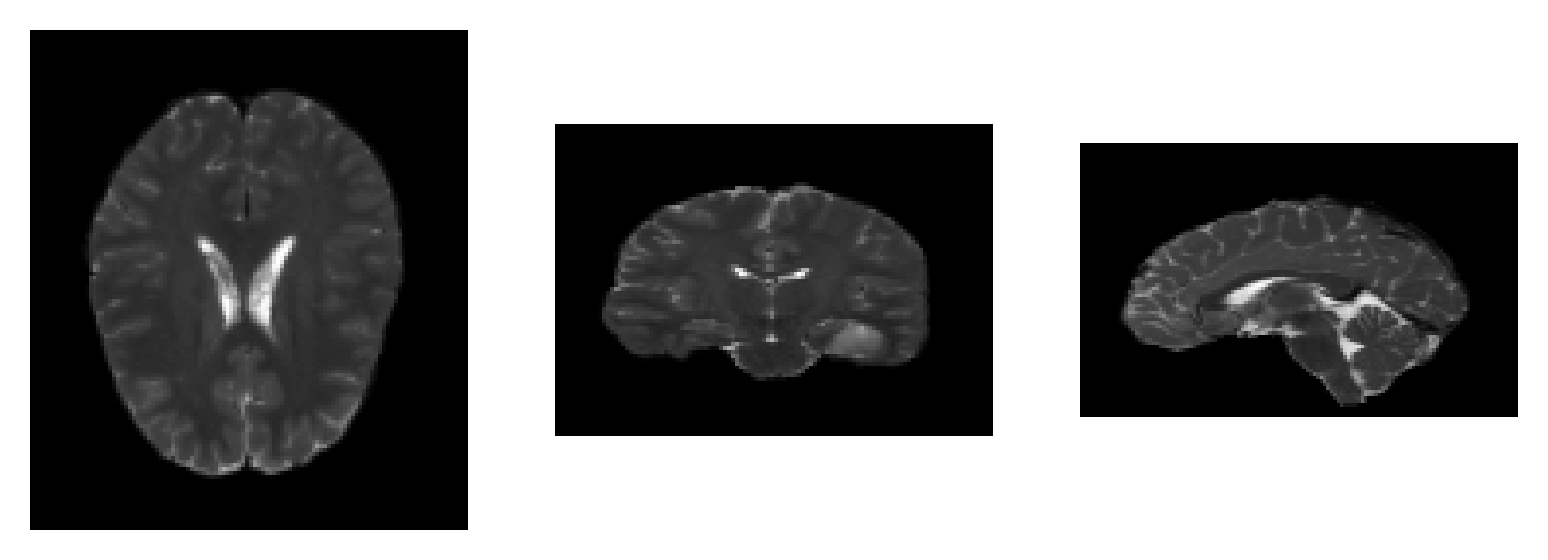

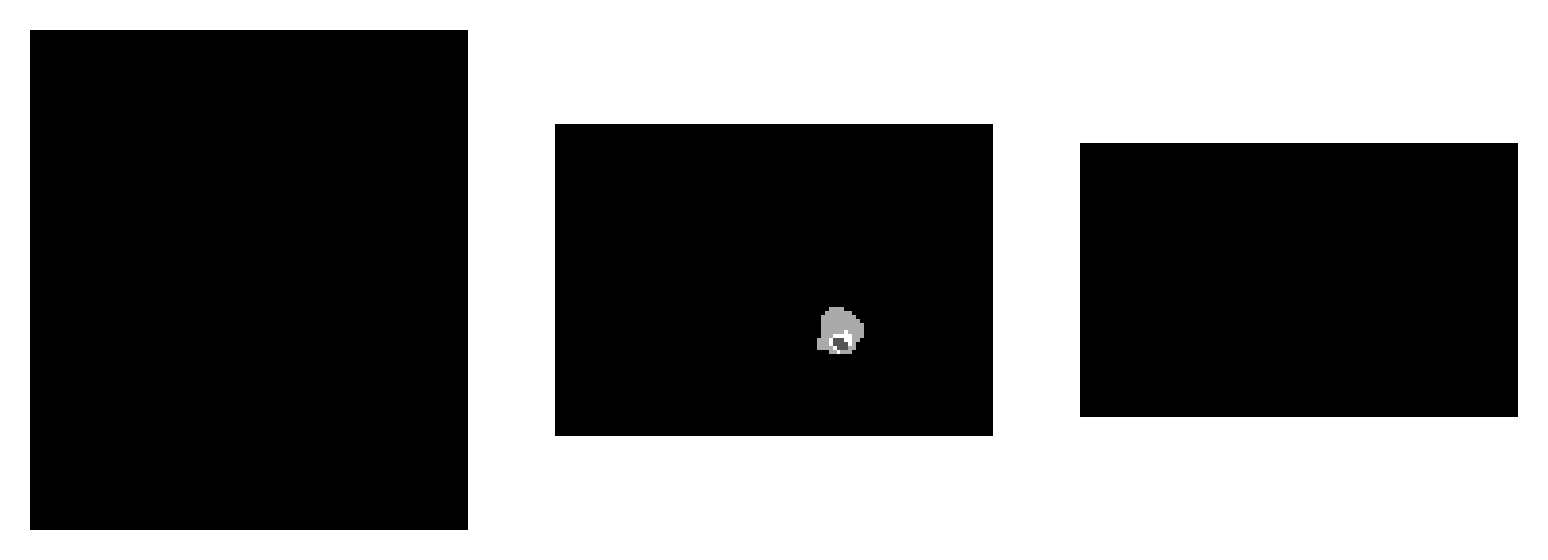

A T2 MRI with a small lesion, solid enhancement, in the left temporal lobe


In [10]:
check_data = first(train_loader)
# Select the first image from the batch
si = 2
img = train_ds[si]["image"]
fig, axs = plt.subplots(nrows=1, ncols=3, dpi=300)

for ax in axs:
    ax.axis("off")
ax = axs[0]
ax.imshow(img[0, ..., img.shape[3] // 2].rot90(), cmap="gray")
ax = axs[1]
ax.imshow(img[0, :, img.shape[2] // 2, ...].rot90(), cmap="gray")
ax = axs[2]
ax.imshow(img[0, img.shape[1] // 2, ...].rot90(), cmap="gray")
plt.show()

img = train_ds[si]["label"]
fig, axs = plt.subplots(nrows=1, ncols=3, dpi=300)
for ax in axs:
    ax.axis("off")
ax = axs[0]
ax.imshow(img[0, ..., img.shape[3] // 2].rot90(), cmap="gray")
ax = axs[1]
ax.imshow(img[0, :, img.shape[2] // 2, ...].rot90(), cmap="gray")
ax = axs[2]
ax.imshow(img[0, img.shape[1] // 2, ...].rot90(), cmap="gray")
plt.show()

text = train_ds[si]["text"]
print(text)

### VAE with perceptual loss and discriminator

In [11]:
autoencoder = AutoencoderKL(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    latent_channels=8,
    num_channels=[
        64,
        128,
        256,
    ],
    num_res_blocks=2,
    norm_num_groups=32,
    norm_eps=1e-06,
    attention_levels=[
        False,
        False,
        False,
    ],
    with_encoder_nonlocal_attn=False,
    with_decoder_nonlocal_attn=False,
)
print(f"Let's use {torch.cuda.device_count()} GPUs!")
if torch.cuda.device_count() > 1:
    autoencoder = torch.nn.DataParallel(autoencoder)

#load_ae_path = Path('./models', 'autoencoder_T2_best_model.pth').resolve()
#autoencoder.load_state_dict(torch.load(load_ae_path))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
autoencoder.to(device)

Let's use 4 GPUs!


DataParallel(
  (module): AutoencoderKL(
    (encoder): Encoder(
      (blocks): ModuleList(
        (0): Convolution(
          (conv): Conv3d(1, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        )
        (1-2): 2 x ResBlock(
          (norm1): GroupNorm(32, 64, eps=1e-06, affine=True)
          (conv1): Convolution(
            (conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          )
          (norm2): GroupNorm(32, 64, eps=1e-06, affine=True)
          (conv2): Convolution(
            (conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          )
          (nin_shortcut): Identity()
        )
        (3): Downsample(
          (conv): Convolution(
            (conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2))
          )
        )
        (4): ResBlock(
          (norm1): GroupNorm(32, 64, eps=1e-06, affine=True)
          (conv1): Convolution(
            (conv): Conv3d(64, 12

In [12]:
discriminator = PatchDiscriminator(
    spatial_dims=3,
    num_layers_d=3,
    num_channels=32,
    in_channels=1,
    out_channels=1,
    kernel_size=3,
    activation=(Act.LEAKYRELU, {"negative_slope": 0.2}),
    norm="BATCH",
    bias=False,
    padding=1,
)

print(f"Let's use {torch.cuda.device_count()} GPUs!")
if torch.cuda.device_count() > 1:
    discriminator = torch.nn.DataParallel(discriminator)
discriminator.to(device)

Let's use 4 GPUs!


DataParallel(
  (module): PatchDiscriminator(
    (initial_conv): Convolution(
      (conv): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
      (adn): ADN(
        (D): Dropout(p=0.0, inplace=False)
        (A): LeakyReLU(negative_slope=0.2)
      )
    )
    (0): Convolution(
      (conv): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
      (adn): ADN(
        (N): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (D): Dropout(p=0.0, inplace=False)
        (A): LeakyReLU(negative_slope=0.2)
      )
    )
    (1): Convolution(
      (conv): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
      (adn): ADN(
        (N): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (D): Dropout(p=0.0, inplace=False)
        (A): LeakyReLU(negative_slope=0.2)
      )
    )
    (2): Convolution(
      (conv): Conv3d(12

In [14]:
perceptual_loss = PerceptualLoss(spatial_dims=3, network_type="medicalnet_resnet50_23datasets", is_fake_3d=False, cache_dir='.cache')
print(f"Let's use {torch.cuda.device_count()} GPUs!")
if torch.cuda.device_count() > 1:
    perceptual_loss = torch.nn.DataParallel(perceptual_loss)
perceptual_loss.to(device)

adv_loss = PatchAdversarialLoss(criterion="least_squares")
adv_weight = 0.01
perceptual_weight = 0.001

optimizer_g = torch.optim.Adam(autoencoder.parameters(), lr=1e-5)
optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=1e-5)

Let's use 4 GPUs!


In [15]:
scaler_g = torch.cuda.amp.GradScaler()
scaler_d = torch.cuda.amp.GradScaler()

/jobfs/147303305.gadi-pbs/ipykernel_568330/3229811950.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_g = torch.cuda.amp.GradScaler()
/jobfs/147303305.gadi-pbs/ipykernel_568330/3229811950.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_d = torch.cuda.amp.GradScaler()


In [ ]:
kl_weight = 1e-6
n_epochs = 1000
val_interval = 1
epoch_recon_loss_list = []
epoch_gen_loss_list = []
epoch_disc_loss_list = []
val_recon_epoch_loss_list = []
intermediary_images = []
n_example_images = 4
best_loss = float("inf")

for epoch in range(n_epochs):
    autoencoder.train()
    discriminator.train()
    epoch_loss = 0
    gen_epoch_loss = 0
    disc_epoch_loss = 0
    progress_bar = tqdm(enumerate(train_loader), total=len(train_loader), ncols=110)
    progress_bar.set_description(f"Epoch {epoch}")
    for step, batch in progress_bar:
        images = batch["image"].to(device)
        optimizer_g.zero_grad(set_to_none=True)

        # Generator part
        with autocast(enabled=True):
            reconstruction, z_mu, z_sigma = autoencoder(images)
            logits_fake = discriminator(reconstruction.contiguous().float())[-1]

            recons_loss = F.l1_loss(reconstruction.float(), images.float())
            p_loss = perceptual_loss(reconstruction.float(), images.float())
            #p_loss_t1c = perceptual_loss(reconstruction[:, 1].unsqueeze(1).float(), images[:, 1].unsqueeze(1).float())
            #p_loss = (p_loss_flair + p_loss_t1c) / 2
            generator_loss = adv_loss(logits_fake, target_is_real=True, for_discriminator=False)

            kl_loss = 0.5 * torch.sum(z_mu.pow(2) + z_sigma.pow(2) - torch.log(z_sigma.pow(2)) - 1, dim=[1, 2, 3, 4])
            kl_loss = torch.sum(kl_loss) / kl_loss.shape[0]

            loss_g = recons_loss + (kl_weight * kl_loss) + (perceptual_weight * p_loss.mean()) + (adv_weight * generator_loss)

        scaler_g.scale(loss_g).backward()
        scaler_g.step(optimizer_g)
        scaler_g.update()

        # Discriminator part
        optimizer_d.zero_grad(set_to_none=True)

        with autocast(enabled=True):
            logits_fake = discriminator(reconstruction.contiguous().detach())[-1]
            loss_d_fake = adv_loss(logits_fake, target_is_real=False, for_discriminator=True)
            logits_real = discriminator(images.contiguous().detach())[-1]
            loss_d_real = adv_loss(logits_real, target_is_real=True, for_discriminator=True)
            discriminator_loss = (loss_d_fake + loss_d_real) * 0.5

            loss_d = adv_weight * discriminator_loss

        scaler_d.scale(loss_d).backward()
        scaler_d.step(optimizer_d)
        scaler_d.update()

        epoch_loss += recons_loss.item()
        gen_epoch_loss += generator_loss.item()
        disc_epoch_loss += discriminator_loss.item()

        progress_bar.set_postfix(
            {
                "recons_loss": epoch_loss / (step + 1),
                "gen_loss": gen_epoch_loss / (step + 1),
                "disc_loss": disc_epoch_loss / (step + 1),
            }
        )
    epoch_recon_loss_list.append(epoch_loss / (step + 1))
    epoch_gen_loss_list.append(gen_epoch_loss / (step + 1))
    epoch_disc_loss_list.append(disc_epoch_loss / (step + 1))

    if (epoch + 1) % val_interval == 0:
        autoencoder.eval()
        val_loss = 0
        with torch.no_grad():
            for val_step, batch in enumerate(val_loader, start=1):
                images = batch["image"].to(device)
                optimizer_g.zero_grad(set_to_none=True)

                reconstruction, z_mu, z_sigma = autoencoder(images)
                # get the first sammple from the first validation batch for visualisation
                # purposes
                if val_step == 1:
                    intermediary_images.append(reconstruction[:n_example_images, 0])

                recons_loss = F.l1_loss(reconstruction.float(), images.float())

                val_loss += recons_loss.item()

        val_loss /= val_step
        if val_loss < best_loss:
            print('new best validation loss = {:0.3f}'.format(val_loss))
            torch.save(autoencoder.state_dict(), './models/autoencoder_T2_best_model.pth')
            best_loss = val_loss
        else:
            torch.save(autoencoder.state_dict(), './models/autoencoder_T2_checkpoint.pth')
                  
        val_recon_epoch_loss_list.append(val_loss)

progress_bar.close()
np.savetxt('vae_T2_recon_loss_list.txt', epoch_recon_loss_list)
np.savetxt('vae_T2_gen_loss_list.txt', epoch_gen_loss_list)
np.savetxt('vae_T2_disc_loss_list.txt', epoch_disc_loss_list)
print('training finished')

Epoch 0:   0%|                                                                        | 0/185 [00:00<?, ?it/s]/jobfs/147303305.gadi-pbs/ipykernel_568330/2631167913.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
/scratch/hl36/nk9793/venv/monai_res3/lib/python3.9/site-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/jobfs/147303305.gadi-pbs/ipykernel_568330/2631167913.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
Epoch 0: 100%|█████████| 185/185 [01:54<00:00,  1.61it/s, recons_loss=0.0705, gen_loss=0.714, disc_loss=0.328]


new best validation loss = 0.044


Epoch 1: 100%|█████████| 185/185 [01:51<00:00,  1.66it/s, recons_loss=0.0424, gen_loss=0.716, disc_loss=0.183]


new best validation loss = 0.040


Epoch 4: 100%|█████████| 185/185 [01:50<00:00,  1.67it/s, recons_loss=0.0396, gen_loss=0.469, disc_loss=0.182]


new best validation loss = 0.038


Epoch 5: 100%|█████████| 185/185 [01:50<00:00,  1.67it/s, recons_loss=0.0384, gen_loss=0.409, disc_loss=0.205]


new best validation loss = 0.038


Epoch 6:  32%|███▌       | 59/185 [00:36<01:18,  1.61it/s, recons_loss=0.038, gen_loss=0.381, disc_loss=0.221]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


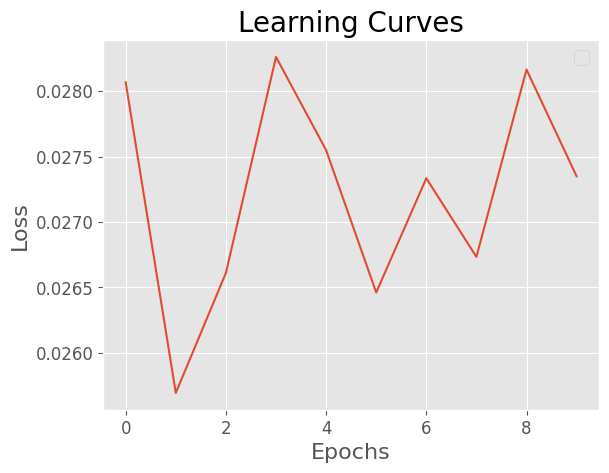

In [37]:
plt.style.use("ggplot")
plt.title("Learning Curves", fontsize=20)
plt.plot(epoch_recon_loss_list)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.xlabel("Epochs", fontsize=16)
plt.ylabel("Loss", fontsize=16)
plt.legend(prop={"size": 14})
plt.show()

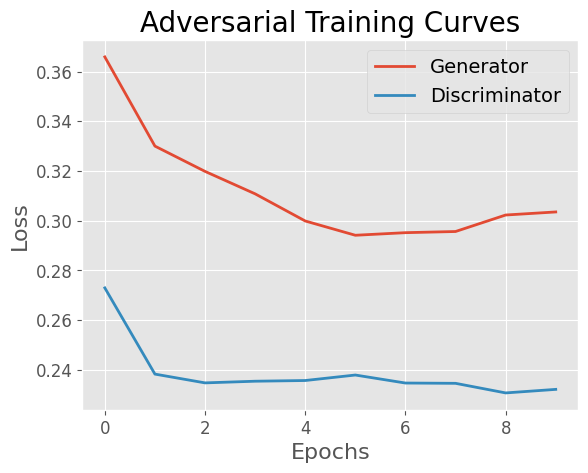

In [38]:
plt.title("Adversarial Training Curves", fontsize=20)
plt.plot(epoch_gen_loss_list, color="C0", linewidth=2.0, label="Generator")
plt.plot(epoch_disc_loss_list, color="C1", linewidth=2.0, label="Discriminator")
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.xlabel("Epochs", fontsize=16)
plt.ylabel("Loss", fontsize=16)
plt.legend(prop={"size": 14})
plt.show()

In [39]:
del discriminator
torch.cuda.empty_cache()

### Define tokenizer and LLM

In [6]:
from transformers import AutoTokenizer, CLIPTextModel
import torch
import torch.nn as nn
from typing import List

dataroot = '/g/data/hl36/mhf/monai/Task03_BrainTumourDx'
# Load the pre-trained CLIP model for text encoding
clip_model = CLIPTextModel.from_pretrained("stabilityai/stable-diffusion-2-1-base", subfolder="text_encoder", cache_dir=Path(dataroot, '.cache').resolve())
if torch.cuda.device_count() > 1:
    clip_model = torch.nn.DataParallel(clip_model)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
clip_model.to(device)
clip_processor = AutoTokenizer.from_pretrained("stabilityai/stable-diffusion-2-1-base", subfolder="tokenizer", cache_dir=Path(dataroot, '.cache').resolve())

clip_model.eval()  # your CLIPTextModel
for p in clip_model.parameters(): p.requires_grad_(False)

@torch.no_grad()
def encode_text(tokenizer, texts, device, pad_to_max=True):
    # always pad/truncate to the model's max length to ensure same T
    tok = tokenizer(
        text=texts,
        max_length=tokenizer.model_max_length,
        return_tensors="pt",
        truncation=True,
        padding="max_length" if pad_to_max else "longest"
    ).to(device)
    out = clip_model(**tok)
    return out.last_hidden_state

# cache an unconditional embedding per batch-size you use
def get_uncond(tokenizer, batch_size, device):
    return encode_text(tokenizer, [""] * batch_size, device)

def prepare_conditioning(tokenizer, text_list, device, dropout_p=0.2, uncond_cache=None):
    B = len(text_list)
    cond = encode_text(tokenizer, text_list, device)                 # [B, T, D]
    uncond = uncond_cache if (uncond_cache is not None and uncond_cache.size(0) == B) \
             else get_uncond(tokenizer, B, device)                   # [B, T, D]
    # text-dropout for CFG training
    drop = (torch.rand(B, device=device) < dropout_p).float().view(B, 1, 1)
    context = cond * (1.0 - drop) + uncond * drop                    # [B, T, D]
    return context, uncond

### Define LDM and scheduler

In [7]:
set_determinism(42)
VAL_AMP = True
diffusion_model = DiffusionModelUNet(
    spatial_dims=3,
    in_channels=8,
    out_channels=8,
    num_channels=[
        256,
        512,
        768,
    ],
    num_res_blocks=2,
    attention_levels=[
        False,
        True,
        True,
    ],
    norm_num_groups=32,
    norm_eps=1e-06,
    resblock_updown=True,
    num_head_channels=[
        0,
        64,
        64,
    ],
    with_conditioning=True,
    transformer_num_layers=1,
    cross_attention_dim=1024,
    upcast_attention=True,
    use_flash_attention=False,
)

from monai.losses import GeneralizedDiceLoss
from monai.metrics import GeneralizedDiceScore


#dice_loss = GeneralizedDiceLoss(to_onehot_y=False, sigmoid=True)
# bce_loss = nn.BCEWithLogitsLoss()
# l1_loss = nn.L1Loss()
post_sigmoid = transforms.Activations(sigmoid=True)
post_pred = transforms.AsDiscrete(argmax=False, threshold=0.5)

#dice_metric_batch = GeneralizedDiceScore(include_background=True, reduction="mean_batch")
#dice_metric_batch = DiceMetric(include_background=True, reduction="mean_batch")

post_trans = transforms.Compose([transforms.Activations(sigmoid=True), transforms.AsDiscrete(threshold=0.68)])

# define inference method
def inference(input):
    def _compute(input):
        return sliding_window_inference(
            roi_size=None,
            inputs=input,
            sw_batch_size=1,
            predictor=diffusion_model,
            overlap=0.5,
        )

    if VAL_AMP:
        with autocast(enabled=True):
            return _compute(input)
    else:
        return _compute(input)

# use multiple GPUs
print(f"Let's use {torch.cuda.device_count()} GPUs!")
if torch.cuda.device_count() > 1:
    diffusion_model = torch.nn.DataParallel(diffusion_model)
    # dice_loss = torch.nn.DataParallel(dice_loss)
    # bce_loss = torch.nn.DataParallel(bce_loss)
    # l1_loss = torch.nn.DataParallel(l1_loss)

#diffusion_model_pth = './models/diffusion_flair_best_model.pth'
#diffusion_model.module.load_state_dict(torch.load(diffusion_model_pth))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

diffusion_model.to(device)
#dice_loss.to(device)

Let's use 4 GPUs!


DataParallel(
  (module): DiffusionModelUNet(
    (conv_in): Convolution(
      (conv): Conv3d(8, 256, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    )
    (time_embed): Sequential(
      (0): Linear(in_features=256, out_features=1024, bias=True)
      (1): SiLU()
      (2): Linear(in_features=1024, out_features=1024, bias=True)
    )
    (down_blocks): ModuleList(
      (0): DownBlock(
        (resnets): ModuleList(
          (0-1): 2 x ResnetBlock(
            (norm1): GroupNorm(32, 256, eps=1e-06, affine=True)
            (nonlinearity): SiLU()
            (conv1): Convolution(
              (conv): Conv3d(256, 256, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
            )
            (time_emb_proj): Linear(in_features=1024, out_features=256, bias=True)
            (norm2): GroupNorm(32, 256, eps=1e-06, affine=True)
            (conv2): Convolution(
              (conv): Conv3d(256, 256, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
  

In [8]:
optimizer = torch.optim.AdamW(diffusion_model.parameters(), lr=2.5e-5)
scheduler = DDIMScheduler(
    beta_start=0.0015,
    beta_end=0.0205,
    num_train_timesteps=1000,
    schedule="scaled_linear_beta",
    clip_sample=False,
    prediction_type="v_prediction",
)
scaler = torch.cuda.amp.GradScaler()

/jobfs/147303305.gadi-pbs/ipykernel_378760/2437456389.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [9]:
inferer = DiffusionInferer(scheduler)

#### Reload VAE

In [10]:
autoencoder = AutoencoderKL(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    latent_channels=8,
    num_channels=[
        64,
        128,
        256,
    ],
    num_res_blocks=2,
    norm_num_groups=32,
    norm_eps=1e-06,
    attention_levels=[
        False,
        False,
        False,
    ],
    with_encoder_nonlocal_attn=False,
    with_decoder_nonlocal_attn=False,
)
print(f"Let's use {torch.cuda.device_count()} GPUs!")
if torch.cuda.device_count() > 1:
    autoencoder = torch.nn.DataParallel(autoencoder)

load_ae_path = Path('./models', 'autoencoder_T2_best_model.pth').resolve()
autoencoder.load_state_dict(torch.load(load_ae_path))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
autoencoder.to(device)

Let's use 4 GPUs!


DataParallel(
  (module): AutoencoderKL(
    (encoder): Encoder(
      (blocks): ModuleList(
        (0): Convolution(
          (conv): Conv3d(1, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        )
        (1-2): 2 x ResBlock(
          (norm1): GroupNorm(32, 64, eps=1e-06, affine=True)
          (conv1): Convolution(
            (conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          )
          (norm2): GroupNorm(32, 64, eps=1e-06, affine=True)
          (conv2): Convolution(
            (conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          )
          (nin_shortcut): Identity()
        )
        (3): Downsample(
          (conv): Convolution(
            (conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2))
          )
        )
        (4): ResBlock(
          (norm1): GroupNorm(32, 64, eps=1e-06, affine=True)
          (conv1): Convolution(
            (conv): Conv3d(64, 12

In [11]:
class Stage1Wrapper(nn.Module):
    """Wrapper for stage 1 model as a workaround for the DataParallel usage in the training loop."""

    def __init__(self, model: nn.Module) -> None:
        super().__init__()
        self.model = model

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z_mu, z_sigma = self.model.encode(x)
        z = self.model.sampling(z_mu, z_sigma)
        return z
        
stage1 = autoencoder.module
stage1 = Stage1Wrapper(model=stage1)
if torch.cuda.device_count() > 1:
    stage1 = torch.nn.DataParallel(stage1)
    
stage1.to(device)
stage1.eval()

DataParallel(
  (module): Stage1Wrapper(
    (model): AutoencoderKL(
      (encoder): Encoder(
        (blocks): ModuleList(
          (0): Convolution(
            (conv): Conv3d(1, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          )
          (1-2): 2 x ResBlock(
            (norm1): GroupNorm(32, 64, eps=1e-06, affine=True)
            (conv1): Convolution(
              (conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
            )
            (norm2): GroupNorm(32, 64, eps=1e-06, affine=True)
            (conv2): Convolution(
              (conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
            )
            (nin_shortcut): Identity()
          )
          (3): Downsample(
            (conv): Convolution(
              (conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2))
            )
          )
          (4): ResBlock(
            (norm1): GroupNorm(32, 64, eps=1e-06, affi

In [16]:
with torch.no_grad():
    with autocast(enabled=True):
        z = autoencoder.module.encode_stage_2_inputs(check_data["image"].to(device))

print(f"Scaling factor set to {1/torch.std(z)}")
scale_factor = 1 / torch.std(z)

/jobfs/147303305.gadi-pbs/ipykernel_378760/3889856643.py:2: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


Scaling factor set to 1.0021588802337646


### Train LDM

In [17]:
def train_ldm(
    model: nn.Module,
    stage1: nn.Module,
    scheduler: nn.Module,
    inferer: nn.Module,
    start_epoch: int,
    best_loss: float,
    train_loader: torch.utils.data.DataLoader,
    val_loader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    tokenizer,
    n_epochs: int,
    eval_freq: int,
    device: torch.device,
    run_dir: Path,
    scale_factor: float,
) -> float:
    scaler = GradScaler()
    raw_model = model.module if hasattr(model, "module") else model

    val_loss = eval_ldm(
        model=model,
        stage1=stage1,
        scheduler=scheduler,
        inferer=inferer,
        loader=val_loader,
        tokenizer=tokenizer,
        device=device,
        step=len(train_loader) * start_epoch,
        sample=False,
        scale_factor=1.0,
    )
    print(f"epoch {start_epoch} val loss: {val_loss:.4f}")
    
    for epoch in range(start_epoch, n_epochs):
        train_epoch_ldm(
            model=model,
            stage1=stage1,
            scheduler=scheduler,
            inferer=inferer,
            loader=train_loader,
            optimizer=optimizer,
            tokenizer=tokenizer,
            device=device,
            epoch=epoch,
            scaler=scaler,
            scale_factor=scale_factor,
        )

        if (epoch + 1) % eval_freq == 0:
            val_loss = eval_ldm(
                model=model,
                stage1=stage1,
                scheduler=scheduler,
                inferer=inferer,
                loader=val_loader,
                tokenizer=tokenizer,
                device=device,
                step=len(train_loader) * epoch,
                sample=True if (epoch + 1) % (eval_freq * 2) == 0 else False,
                scale_factor=scale_factor,
            )

            print(f"epoch {epoch + 1} val loss: {val_loss:.4f}")
            with open(Path(dataroot, "ldm_val_T2_losses.txt"), 'a+') as f:
                f.write(f"\n{val_loss}")

            # Save checkpoint
            checkpoint = {
                "epoch": epoch + 1,
                "diffusion": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "best_loss": best_loss,
            }
            torch.save(checkpoint, str(run_dir + "diffusion_T2_checkpoint.pth"))

            if val_loss <= best_loss:
                print(f"New best val loss {val_loss}")
                best_loss = val_loss
                torch.save(raw_model.state_dict(), str(run_dir + "diffusion_T2_best_model.pth"))

    print(f"Training finished!")
    print(f"Saving final model...")
    torch.save(raw_model.state_dict(), str(run_dir + "diffusion_T2_final_model.pth"))

    return val_loss

def train_epoch_ldm(
    model: nn.Module,
    stage1: nn.Module,
    scheduler: nn.Module,
    inferer: nn.Module,
    loader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    tokenizer,
    device: torch.device,
    epoch: int,
    scaler: GradScaler,
    scale_factor: float,
) -> None:
    model.train()

    pbar = tqdm(enumerate(loader), total=len(loader))
    for step, batch in pbar:
        context, _ = prepare_conditioning(tokenizer, batch["text"], device, dropout_p=0.2, uncond_cache=None)
        images = batch["image"].to(device)
        #t1c = images[:, 0].unsqueeze(1)
        #true_seg = batch["label"].to(device)
        # text = batch["text"]
        # reports = clip_processor(
        #     text=text,
        #     max_length=clip_processor.model_max_length, 
        #     return_tensors="pt", 
        #     truncation=True, 
        #     padding=True
        # ).to(device)
        # prompt_embeds = clip_model(**reports.to(device))
        # condition = prompt_embeds[0].to(device)
        
        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=True):
            with torch.no_grad():
                e = stage1(images) * scale_factor

            noise = torch.randn_like(e)  # e.g., latents from VAE.encode
            timesteps = torch.randint(0, scheduler.num_train_timesteps, (e.size(0),), device=device, dtype=torch.long)
            noisy = scheduler.add_noise(e, noise, timesteps)
            
            # predict noise with text context
            noise_pred = diffusion_model(x=noisy, timesteps=timesteps, context=context)
                
            # noise = torch.randn_like(e).to(device)
            # timesteps = torch.randint(
            #     0, scheduler.num_train_timesteps, (images.shape[0],), device=images.device
            # ).long()
            # noisy_e = scheduler.add_noise(original_samples=e, noise=noise, timesteps=timesteps)
            
            # noise_pred = model(x=noisy_e, timesteps=timesteps, context=condition)

            if scheduler.prediction_type == "v_prediction":
                # Use v-prediction parameterization
                target = scheduler.get_velocity(e, noise, timesteps)
            elif scheduler.prediction_type == "epsilon":
                target = noise
            loss = F.mse_loss(noise_pred.float(), target.float())
            # with torch.no_grad():
            #     out = stage1_out(noise_pred) / scale_factor
            #     fake_seg = post_trans(out)
            # seg_loss = dice_loss(fake_seg, true_seg)
        loss = loss.mean()

        losses = OrderedDict(loss=loss)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        pbar.set_postfix({"epoch": epoch, "loss": f"{losses['loss'].item():.5f}"})


@torch.no_grad()
def eval_ldm(
    model: nn.Module,
    stage1: nn.Module,
    scheduler: nn.Module,
    inferer: nn.Module,
    loader: torch.utils.data.DataLoader,
    tokenizer,
    device: torch.device,
    step: int,
    sample: bool = False,
    scale_factor: float = 1.0,
) -> float:
    model.eval()
    raw_model = model.module if hasattr(model, "module") else model
    total_losses = OrderedDict()

    for step, batch in enumerate(loader):
        images = batch["image"].to(device)
        context, _ = prepare_conditioning(tokenizer, batch["text"], device, dropout_p=0.2, uncond_cache=None)
        #images = batch["image"].to(device)
        #t1c = images[:, 0].unsqueeze(1)
        #true_seg = batch["label"].to(device)
        # text = batch["text"]
        # reports = clip_processor(
        #     text=text,
        #     max_length=clip_processor.model_max_length, 
        #     return_tensors="pt", 
        #     truncation=True, 
        #     padding=True
        # ).to(device)
        # prompt_embeds = clip_model(**reports.to(device))
        # condition = prompt_embeds[0].to(device)
        
        with torch.no_grad():
            with autocast(enabled=True):
                e = stage1(images) * scale_factor
    
                noise = torch.randn_like(e)  # e.g., latents from VAE.encode
                timesteps = torch.randint(0, scheduler.num_train_timesteps, (e.size(0),), device=device, dtype=torch.long)
                noisy = scheduler.add_noise(e, noise, timesteps)
                
                # predict noise with text context
                noise_pred = diffusion_model(x=noisy, timesteps=timesteps, context=context)
        
                if scheduler.prediction_type == "v_prediction":
                    # Use v-prediction parameterization
                    target = scheduler.get_velocity(e, noise, timesteps)
                elif scheduler.prediction_type == "epsilon":
                    target = noise
                loss = F.mse_loss(noise_pred.float(), target.float())

        loss = loss.mean()
        losses = OrderedDict(loss=loss)

        for k, v in losses.items():
            total_losses[k] = total_losses.get(k, 0) + v.item() * images.shape[0]

    for k in total_losses.keys():
        total_losses[k] /= len(loader.dataset)

    return total_losses["loss"]

In [ ]:
best_loss = float("inf")
start_epoch = 0

val_loss = train_ldm(
    model=diffusion_model,
    stage1=stage1,
    scheduler=scheduler,
    inferer=inferer,
    start_epoch=start_epoch,
    best_loss=best_loss,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    tokenizer=clip_processor,
    n_epochs=1000,
    eval_freq=1,
    device=device,
    run_dir='./models/',
    scale_factor=scale_factor,
)

#### transfer models from /scratch/hl36/mhf/monai/Task03_BrainTumourDx/models/ to /g/data/hl36/mhf/monai/Task03_BrainTumourDx/models/

/jobfs/147303305.gadi-pbs/ipykernel_378760/2686527076.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/jobfs/147303305.gadi-pbs/ipykernel_378760/2686527076.py:196: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


epoch 0 val loss: 1.0022


  0%|          | 0/185 [00:00<?, ?it/s]/jobfs/147303305.gadi-pbs/ipykernel_378760/2686527076.py:121: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
100%|██████████| 185/185 [02:14<00:00,  1.38it/s, epoch=0, loss=0.99998]


epoch 1 val loss: 1.0030
New best val loss 1.0029671630343875


100%|██████████| 185/185 [02:13<00:00,  1.39it/s, epoch=1, loss=0.99889]


...

100%|██████████| 185/185 [02:13<00:00,  1.38it/s, epoch=11, loss=0.98871]


epoch 12 val loss: 0.9914
New best val loss 0.9914146816408312


100%|██████████| 185/185 [02:12<00:00,  1.39it/s, epoch=12, loss=0.98472]


epoch 13 val loss: 0.9915


 25%|██▌       | 47/185 [00:33<01:37,  1.41it/s, epoch=13, loss=0.99611]

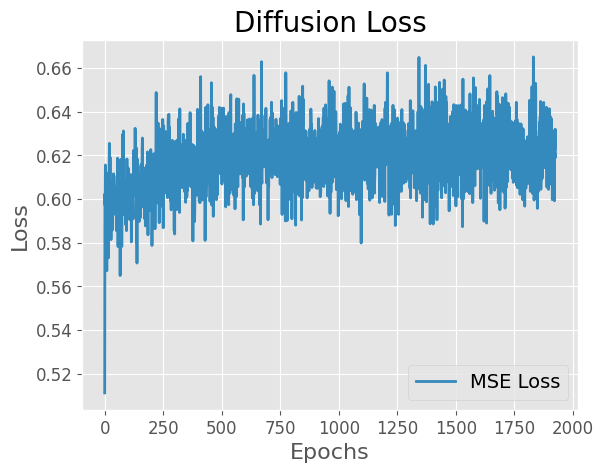

In [3]:
plt.style.use("ggplot")
epoch_ldm_loss = np.loadtxt("ldm_val_T2_losses.txt")
plt.title("Diffusion Loss", fontsize=20)
#plt.plot(epoch_gen_loss_list, color="C0", linewidth=2.0, label="Generator")
plt.plot(epoch_ldm_loss, color="C1", linewidth=2.0, label="MSE Loss")
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.xlabel("Epochs", fontsize=16)
plt.ylabel("Loss", fontsize=16)
plt.legend(prop={"size": 14})
plt.show()

## generate samples for seg test

In [ ]:
from sklearn.utils.validation import check_random_state
set_timesteps = scheduler.set_timesteps(num_inference_steps=50)
samples = []
rs = check_random_state(42)
grades = [2, 3]

SEX = {
    0: 'male',
    1: 'female'
}
DIAG = {
    0: "Astrocytoma, IDH-mutant",
    1: "Oligodendroglioma, IDH-mutant, 1p/19q-codeleted",
    2: "Astrocytoma, IDH-wildtype",
}
GRADE = {
    0: rs.randint(2, 3),
    1: 2,
    2: 3,
}
notes = []
for _ in range(1000):
    diag_ind = rs.randint(0, 3)
    diagnosis = DIAG.get(diag_ind)
    grade = GRADE.get(diag_ind)
    sex = SEX.get(rs.randint(0, 2))
    age = rs.randint(17, 94)
    notes.append(f"diagnosis of {diagnosis}, WHO Grade {grade}, {sex} aged {age}")

autoencoder.eval()
diffusion_model.eval()
# #t = transforms.AdjustContrast(gamma=2.0, invert_image=False)

with torch.no_grad():
    for i, grade in tqdm(enumerate(notes), total=len(notes)):
        noise = torch.randn((1, 8, 28, 32, 20)).to(device)
        reports = clip_processor(
                    text=notes[i],
                    max_length=clip_processor.model_max_length, 
                    return_tensors="pt", 
                    truncation=True, 
                    padding=True
                ).to(device)
        prompt_embeds = clip_model(**reports.to(device))
        condition = prompt_embeds[0].to(device)
        sample = autoencoder.module.decode_stage_2_outputs(
            inferer.sample(input_noise=noise, diffusion_model=diffusion_model, scheduler=scheduler, conditioning=condition)
        )
        samples.append(sample)

  0%|          | 0/1000 [00:00<?, ?it/s]
%|          | 0/50 [00:00<?, ?it/s]
%|▏         | 1/50 [00:00<00:23,  2.09it/s]
%|▌         | 3/50 [00:00<00:11,  4.11it/s]
%|▊         | 4/50 [00:01<00:11,  3.99it/s]
%|█         | 5/50 [00:01<00:11,  3.87it/s]
%|█▏        | 6/50 [00:01<00:11,  3.99it/s]
%|█▍        | 7/50 [00:01<00:11,  3.91it/s]
%|█▌        | 8/50 [00:02<00:10,  3.95it/s]
%|█▊        | 9/50 [00:02<00:10,  3.88it/s]
%|██        | 10/50 [00:02<00:10,  3.83it/s]
%|██▏       | 11/50 [00:02<00:09,  3.96it/s]
%|██▍       | 12/50 [00:03<00:09,  3.93it/s]
%|██▌       | 13/50 [00:03<00:09,  3.97it/s]
%|██▊       | 14/50 [00:03<00:09,  3.97it/s]
%|███       | 15/50 [00:03<00:09,  3.88it/s]
%|███▏      | 16/50 [00:04<00:08,  4.00it/s]
%|███▍      | 17/50 [00:04<00:08,  3.90it/s]
%|███▌      | 18/50 [00:04<00:08,  3.92it/s]
%|███▊      | 19/50 [00:04<00:07,  3.91it/s]
%|████      | 20/50 [00:05<00:07,  3.84it/s]
%|████▏     | 21/50 [00:05<00:07,  3.95it/s]
%|████▍     | 22/50 [00:05<00:0

In [299]:
awt = 0
amut = 0
oli = 0
grade2 = 0
grade3 = 0
ages = []
male = 0
female = 0
for line in notes:
    if "Astrocytoma, IDH-wildtype" in line:
        awt += 1
    elif "Astrocytoma, IDH-mutant" in line:
        amut += 1
    elif "Oligo" in line:
        oli += 1
    ages.append(int(line.strip(' ')[-2:]))
    if "male" in line and not "female" in line:
        male += 1
    elif "female" in line:
        female += 1
    if "Grade 2" in line:
        grade2 += 1
    elif "Grade 3" in line:
        grade3 += 1

In [302]:
amut

347

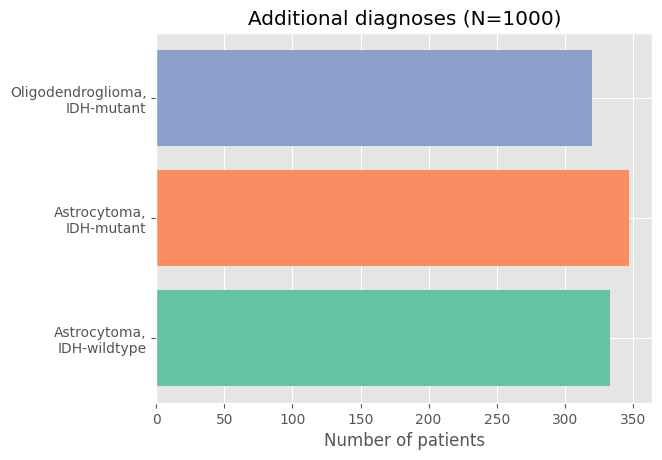

In [304]:
# plot diagnoses, ages, and sexes
import matplotlib as mpl
diagnosis = ['Astrocytoma,\nIDH-wildtype', 'Astrocytoma,\nIDH-mutant', 'Oligodendroglioma,\nIDH-mutant']
bar_colors = mpl.cm.Set2.colors

plt.barh(diagnosis, np.array([awt, amut, oli]), color=bar_colors)
plt.xlabel("Number of patients")
plt.title("Additional diagnoses (N=1000)")
plt.show()

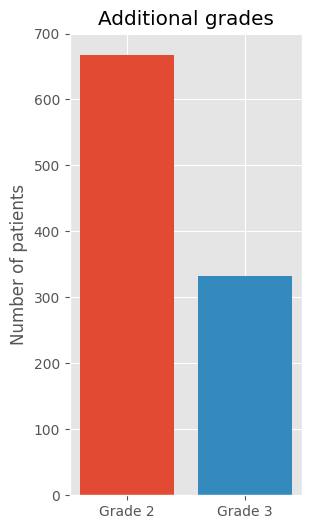

In [305]:
grades = ["Grade 2", "Grade 3"]
fig, ax = plt.subplots(figsize=(3, 6))
plt.bar(grades, np.array([grade2, grade3]), color=['C0', 'C1'])
plt.title("Additional grades")
plt.ylabel("Number of patients")
plt.show()

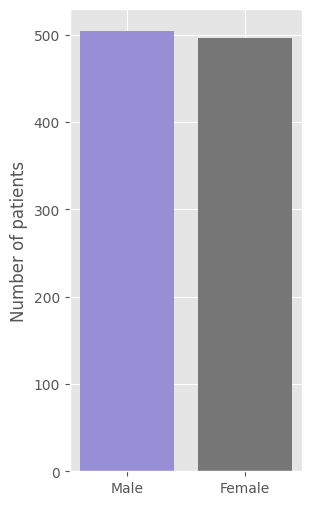

In [306]:
sexes = ["Male", "Female"]
fig, ax = plt.subplots(figsize=(3, 6))
plt.bar(sexes, np.array([male, female]), color=['C2', 'C3'])
#plt.title("Additional grades")
plt.ylabel("Number of patients")
plt.show()

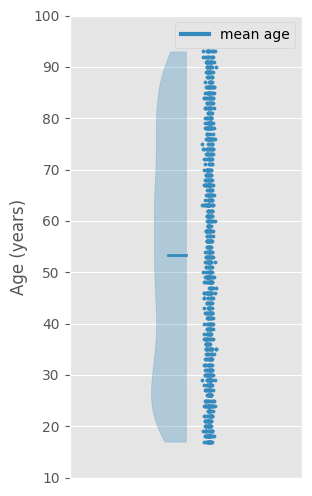

In [307]:
import pandas as pd

df = pd.DataFrame(ages)
fig, ax = plt.subplots(figsize=(3, 6))
v1 = plt.violinplot(df, points=200, showmeans=True, showextrema=False, widths=0.3, side='low')
for b in v1['bodies']:
    # m = np.mean(b.get_paths()[0].vertices[:, 0])
    # b.get_paths()[0].vertices[:, 0] = np.clip(b.get_paths()[0].vertices[:, 0], -np.inf, m)
    b.set_color('C1')

v1['cmeans'].set_color('C1')
v1['cmeans'].set_linewidth(2)

plt.autoscale()
plt.scatter(1.1+0.01*np.random.standard_normal(len(ages)), ages, color='C1', s=5)
plt.xlim([0.5, 1.5])
plt.ylim([10, 100])
plt.xticks([])
plt.ylabel('Age (years)')
plt.legend([mpl.lines.Line2D([0, 1], [0, 1], color='C1', linewidth=3)], ['mean age'], loc='upper right')
#plt.title('Additional ages')
plt.show()

In [308]:
notes

['diagnosis of Astrocytoma, IDH-wildtype, WHO Grade 3, female aged 31',
 'diagnosis of Astrocytoma, IDH-wildtype, WHO Grade 3, female aged 77',
 'diagnosis of Astrocytoma, IDH-mutant, WHO Grade 2, male aged 91',
 'diagnosis of Astrocytoma, IDH-wildtype, WHO Grade 3, female aged 40',
 'diagnosis of Astrocytoma, IDH-wildtype, WHO Grade 3, female aged 69',
 'diagnosis of Oligodendroglioma, IDH-mutant, 1p/19q-codeleted, WHO Grade 2, female aged 46',
 'diagnosis of Oligodendroglioma, IDH-mutant, 1p/19q-codeleted, WHO Grade 2, female aged 80',
 'diagnosis of Astrocytoma, IDH-mutant, WHO Grade 2, male aged 92',
 'diagnosis of Oligodendroglioma, IDH-mutant, 1p/19q-codeleted, WHO Grade 2, female aged 65',
 'diagnosis of Astrocytoma, IDH-wildtype, WHO Grade 3, male aged 58',
 'diagnosis of Astrocytoma, IDH-wildtype, WHO Grade 3, female aged 78',
 'diagnosis of Astrocytoma, IDH-wildtype, WHO Grade 3, female aged 67',
 'diagnosis of Astrocytoma, IDH-wildtype, WHO Grade 3, female aged 80',
 'diagno

### map distribution of samples to heatmap

In [86]:
samples_array = np.array([samples[i][0].cpu() for i in range(len(samples))]).squeeze()
#samples_mu = samples_array.mean(axis=0)
#samples_sigma = samples_array.std(axis=0)
#samples_z = (samples - samples_mu) / samples_sigma
# use a bounding box
# Dimensions of the mask
#image_shape = (112, 128, 80)
#bbox_shape = (40, 50, 30)

# Calculate the center of the image
#center = (60, 80, 55)

# Calculate the start and end indices for the mask
#start = tuple(c - m // 2 for c, m in zip(center, bbox_shape))
#end = tuple(s + m for s, m in zip(start, bbox_shape))

# Create the full image mask with all False
#bbox = np.zeros(image_shape, dtype=bool)

# Set the region to True
#bbox[start[0]:end[0], start[1]:end[1], start[2]:end[2]] = True

#samples_scaled = np.zeros_like(samples_z)
#samples_scaled[:, bbox] = (samples[:, bbox] - np.min(samples[:, bbox])) / (np.max(samples[:, bbox]) - np.min(samples[:, bbox]))

#samples_95 = np.zeros(image_shape)
#samples_75 = np.zeros(image_shape)
#samples_50 = np.zeros(image_shape)
#samples_heat = np.zeros(image_shape)
#samples_95[bbox] = np.sum(samples_scaled[:, bbox] > 0.95, axis=0) / len(samples)
#samples_75[bbox] = np.sum(samples_scaled[:, bbox] > 0.75, axis=0) / len(samples)
#samples_heat[bbox] = np.sum(samples_scaled[:, bbox], axis=0) / len(samples)
samples_heat = np.sum(samples_array, axis=0) / len(samples_array)
#samples_heat[bbox] = (samples_heat[bbox] - samples_heat[bbox].min()) / (samples_heat[bbox].max() - samples_heat[bbox].min())
#samples_25[bbox] = np.sum(samples_scaled[:, bbox] > 0.25, axis=0) / len(samples)


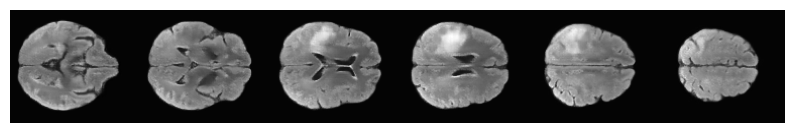

In [154]:
img = torch.tensor(samples_array[4])
fig, ax = plt.subplots(figsize=(10, 60))
ax.axis("off")
image = np.concatenate([
    #img[..., 15], 
    #img[..., 20], 
    #img[..., 25], 
    #img[..., 30], 
    #img[..., 35], 
    img[..., 40],
    img[..., 45],
    img[..., 50],
    img[..., 55],
    img[..., 60],
    img[..., 65],
],
    #img[..., 70]]
axis=1)
plt.imshow(image, cmap='gray')
plt.show()

### plot 

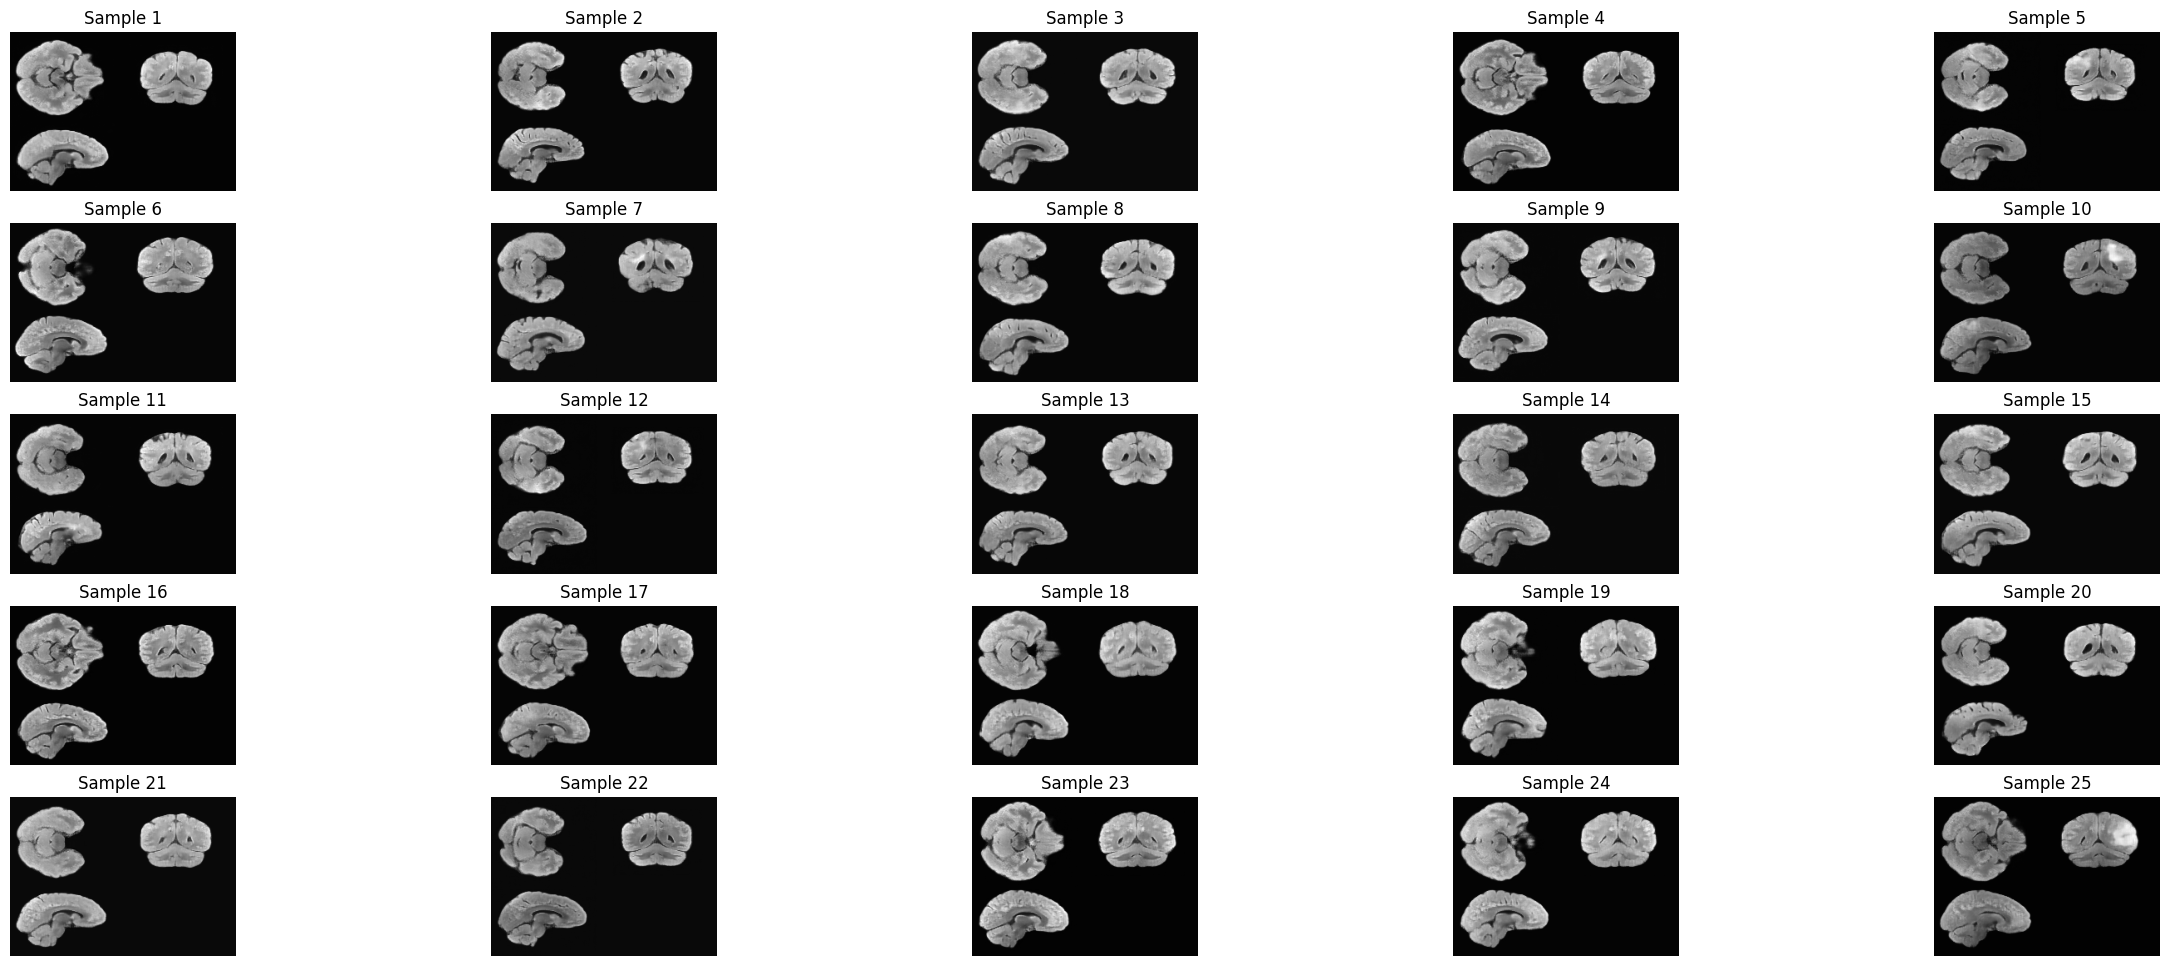

In [96]:
fig, ax = plt.subplots(nrows=5, ncols=5)
plt.style.use("default")
fig.set_size_inches(30, 12)
ii = 0
for i in range(5):
    for j in range(5):
        plotting_image_0 = np.concatenate([samples_array[ii, :, :, 31], np.pad(np.flipud(samples_array[ii, :, 40, :].T), pad_width=16)], axis=1)
        plotting_image_1 = np.concatenate([np.flipud(samples_array[ii, 60, :, :].T), np.zeros((80, 144))], axis=1)
        image = np.concatenate([plotting_image_0, plotting_image_1], axis=0)
        ax[i,j].imshow(image, cmap="gray")
        ax[i,j].axis("off")
        ax[i,j].title.set_text("Sample " + str(ii + 1))
        ii += 1
plt.show()

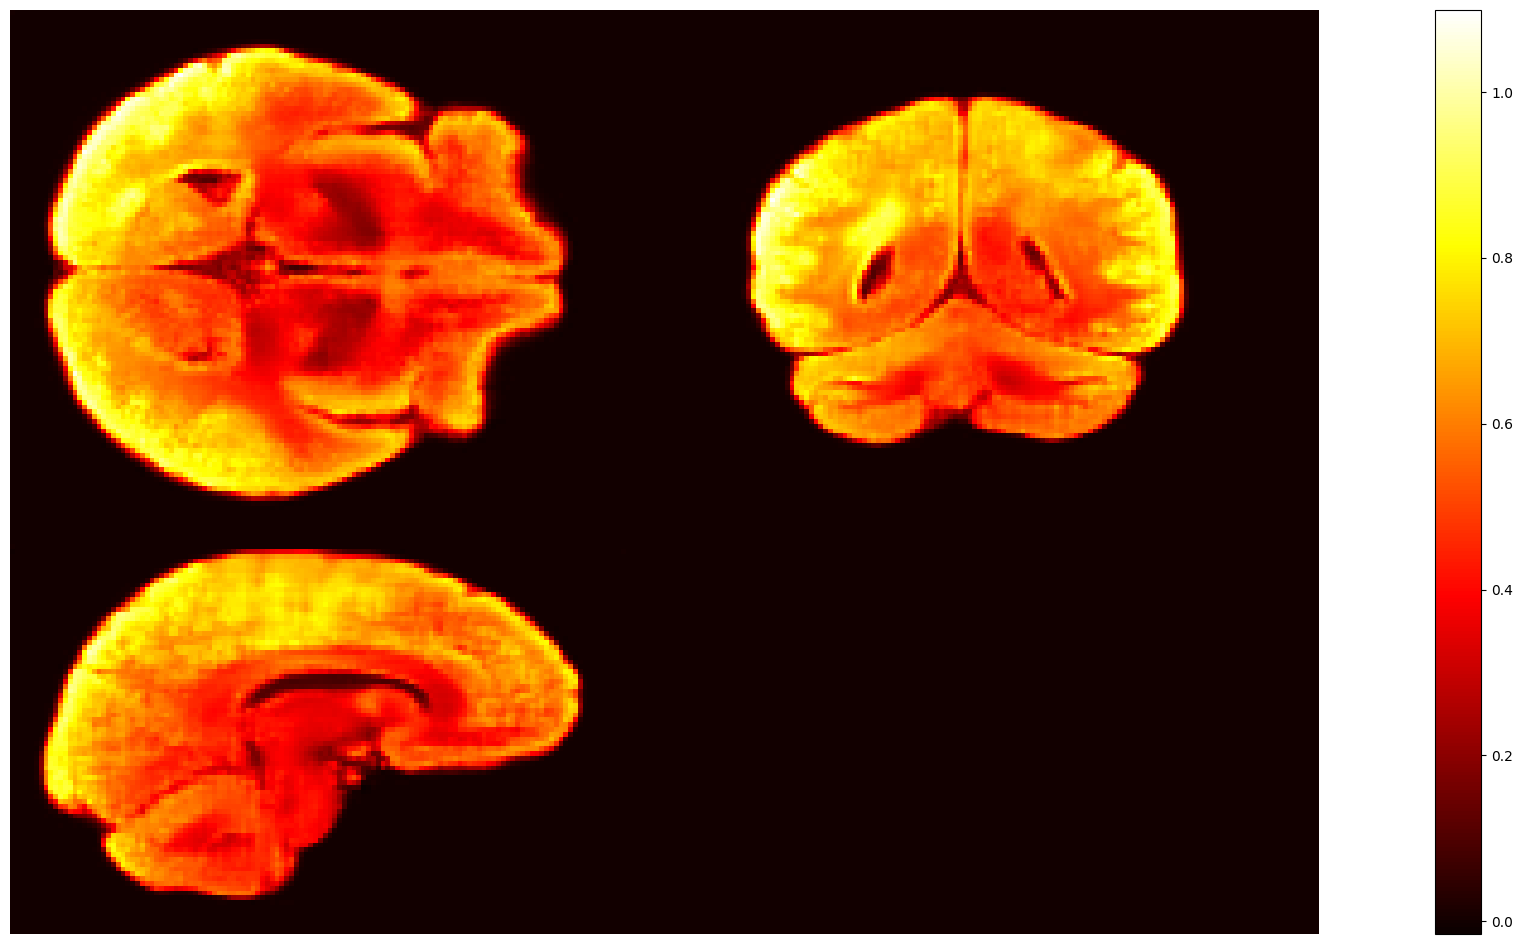

In [22]:
fig, ax = plt.subplots(nrows=1, ncols=1)
plt.style.use("default")
fig.set_size_inches(30, 12)

plotting_image_0 = np.concatenate([samples_heat[:, :, 40], np.pad(np.flipud(samples_heat[:, 40, :].T), pad_width=16)], axis=1)
plotting_image_1 = np.concatenate([np.flipud(samples_heat[60, :, :].T), np.zeros((80, 144))], axis=1)
image = np.concatenate([plotting_image_0, plotting_image_1], axis=0)
cax = ax.imshow(image, cmap="hot")
plt.colorbar(cax)
ax.axis("off")
plt.show()

In [22]:
torch.cuda.empty_cache()

## train LLM for conversation about case

In [26]:
# Load our pretrained tokenizer and text model
from transformers import AutoTokenizer, CLIPTextModel
import torch
import torch.nn as nn

# Load the pre-trained CLIP model for text encoding
clip_model = CLIPTextModel.from_pretrained("stabilityai/stable-diffusion-2-1-base", subfolder="text_encoder", cache_dir=Path(dataroot, '.cache').resolve())
if torch.cuda.device_count() > 1:
    clip_model = torch.nn.DataParallel(clip_model)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
clip_model.to(device)
clip_processor = AutoTokenizer.from_pretrained("stabilityai/stable-diffusion-2-1-base", subfolder="tokenizer", cache_dir=Path(dataroot, '.cache').resolve())

def embed_text(text):
    inputs = clip_processor(text, return_tensors="pt", truncation=True)
    with torch.no_grad():
        # Use mean pooling on the last hidden state as the embedding
        embedding = clip_model(**inputs).last_hidden_state.mean(dim=1)
    return embedding.squeeze().tolist()

# Load the clinical case
with open("data_dictionary_clinical.json", "r") as f:
    clinical_data = json.load(f)

# Combine key text fields for embedding
text_to_embed = clinical_data["nnUNetv2-00001"]["Dx"] + " " + clinical_data["nnUNetv2-00001"]["EOR"]
embedding = embed_text(text_to_embed)
print("Text Embedding:", embedding)

Text Embedding: [-0.2920489013195038, 0.07197751104831696, -0.025970052927732468, -0.05143012851476669, 0.8310658931732178, -1.0511205196380615, -0.4760790765285492, -0.5653032064437866, -0.3351646363735199, 1.0664243698120117, 0.10914602130651474, -0.5134066343307495, -0.1448916494846344, 0.694512128829956, -0.19817274808883667, 0.3100312054157257, 0.4861019253730774, -0.33334851264953613, -1.2885847091674805, 0.22220224142074585, -0.349212646484375, -0.4929421842098236, -0.5797924399375916, -0.11816161125898361, -0.07753898948431015, 0.04087049886584282, 0.10619163513183594, 0.05879836529493332, 0.06357993930578232, -0.552712082862854, -0.08026005327701569, -0.2314065545797348, -0.11668060719966888, 0.022174369543790817, -0.06236812099814415, -0.24427616596221924, -0.09455236047506332, 0.02849765680730343, -0.07604584842920303, -0.044727787375450134, -0.0030912957154214382, 0.4137430787086487, 0.8104245066642761, 0.1225411519408226, 0.28881722688674927, -0.6727854609489441, -0.383997

In [68]:
def get_radiomics_data(patient_id, csv_file="nnunetv2-2024_MappingToCancerArchive_updated.csv"):
    """
    Reads the precomputed radiomics CSV file and returns the row (as a dict)
    corresponding to the given patient_id. Expected CSV columns include:
      - patient_id, volume, shape, texture, intensity, (and other metrics as needed)
    """
    try:
        with open(csv_file, "r") as f:
            reader = csv.DictReader(f)
            for row in reader:
                # Ensure patient_id is compared as string for consistency.
                if row.get("DataID") == str(patient_id):
                    return row
    except Exception as e:
        print("Error reading radiomics data:", e)
    return None

### create dialogue for training

In [88]:
def generate_dialogue(subj, data_dict):
    dialogue = []
    ### create dialogue with clinician, prompted with "What does the tumor profile suggest?"
    ### answer based on data dictionary, with a decision tree
    prompt = ("You are an expert clinical assistant specialized in neuro-oncology. "
              "Your job is to accurately predict clinically impactful findings and make recommendations. "
              "Generate an example case and learn the associations between the radiomics and molecular data. "
             )
    
    age = int(data_dict[subj].get("Age", ""))
    sex = "male" if data_dict[subj].get("Sex", "").lower() == "m" else "female"
    prompt += f"Patient is {sex}, aged {age} years, with malignant glioma."
    prompt += "Radiomics analysis reveals: "
    
    try:
        rad_data = get_radiomics_data(subj, csv_file="/g/data/hl36/mhf/monai/Task03_BrainTumourDx/nnunetv2-2024_MappingToCancerArchive_updated.csv")
        if rad_data:
            for label in ['necrotic', 'edema', 'enhancing']:
                volume = rad_data.get(f"{label}_shape_VoxelVolume", "unknown")
                if volume == "NaN": # check if necrosis present
                    prompt += "No necrosis present. "
                    continue
                sphericity = rad_data.get(f"{label}_shape_Sphericity", "unknown")
                elongation = rad_data.get(f"{label}_shape_Elongation", "unknown")
                surface_area = rad_data.get(f"{label}_shape_SurfaceArea", "unknown")
                #texture = rad_data.get("texture", "unknown")
                intensity = rad_data.get(f"FLAIR_{label}_firstorder_Mean", "unknown")
                prompt += (f"For {label} tumor, a volume of {float(volume):.4f}, a sphericity of {float(sphericity):.4f}, "
                             f"elongation of {float(elongation):.4f}, a surface area of {float(surface_area):.4f}, "
                             f"and a mean FLAIR intensity of {float(intensity):.4f}. ")
        else:
            prompt += "Radiomics data is not available for this patient. "
    except:
        prompt += "Patient identifier missing; unable to retrieve radiomics data. "

    resection = data_dict[subj].get("EOR", "").lower()
    if "gtr" in resection:
        prompt += "Total resection performed is favorable, though caution remains with high-grade tumors. "
    elif "str" in resection:
        prompt += "Sub-total resection indicates residual tumor, worsening prognosis. "
    elif "biopsy" in resection:
        prompt += "Inoperable tumor indicates very poor prognosis. Recommend very aggressive therapies. "
    else:
        prompt += "Extent of resection is not clearly defined. "

    # decision branch on diagnosis and IDH1 status
    diagnosis = data_dict[subj].get("Dx", "")
    idh_status = data_dict[subj].get("IDH1", "").lower()
    grade = data_dict[subj].get("grade", "")
    # decision tree based on Park et al. 2021, WHO Classification Imaging Update for Gliomas, J. Magn. Reson. Imaging
    
    if "oligodengroglioma" in diagnosis.lower():
        prompt += "The tumor is a low grade Oligodendroglioma, IDH-mutant and 1p/19q codeleted. "
    elif "astrocytoma" in diagnosis.lower():
        if grade == 4:
            prompt += "The tumor is an aggressive Astrocytoma, with necrosis or MVP present, IDH-mutant and no 1p/19q codeletion, suggesting worse prognosis. "
        elif idh_status == "wildtype" and grade == 4:
            prompt += "The tumor has been misclassified as an Astrocytoma, when it is IDH-wildtype Glioblastoma, with poor prognosis. "
        else:
            prompt += "The tumor is a low grade Astrocytoma, IDH-mutant, suggesting better prognosis. "
    elif "glioblastoma" in diagnosis.lower():
        prompt += "The tumor is an aggressive Glioblastoma (IDH-wildtype). "
    else:
        prompt += f"The tumor is a lower grade {diagnosis}, with a moderate chance of survival. "

    if grade == 4:
        prompt += "Its high grade (Grade 4) indicates rapid progression, recommend an aggressive course of treatment and preselection for clinical trials. "
    elif grade == 3:
        prompt += "Its intermediate grade (Grade 3) suggests moderate aggressiveness, treat with standard gross total resection if possible and adjuvant therapy. "
    else:
        prompt += "Low grade suggests favorable outcomes, treat with standard gross total resection if possible and adjuvant therapy. Investigate clinical trials particularly for Oligodendroglioma. "

    survival = data_dict[subj].get("OS", None)
    vital = data_dict[subj].get("vital_status", "").lower()
    if survival is not None or "NaN" not in survival:
        survival = int(survival)
        if survival <= 360 and vital == "dead":
            if grade == 2:
                prompt += "Short survival post-diagnosis despite low grade indicates possible non-tumor related death. Further determination of cause of death suggested. "
            else:
                prompt += "Short survival post-diagnosis underscores the tumor's aggressiveness. "
        elif survival <= 360 and vital == "alive":
            prompt += "Long-term survival unknown, patient is still alive at follow-up. "
        else:
            prompt += "Longer survival suggests potential treatment responsiveness. "

    else:
        prompt += "Survival data is unavailable. "

    mgmt = data_dict[subj].get("MGMT_status", "").lower()
    if "positive" in mgmt:
        prompt += "MGMT promoter methylation correlates with poorer outcomes, particularly in high-grade gliomas. "
    elif "negative" in mgmt:
        prompt += "Unmethylated MGMT promoter favors better response to temazolomide and radiotherapy. "
    else:
        prompt += "MGMT promoter status is indeterminate. "

    dialogue.append({
        "prompt": f"{prompt}",
        #"response": f"{response.strip()}"
    })

    return dialogue

In [57]:
def generate_dialogue_conversation(subj, data_dict):
    dialogue = []
    ### create dialogue with clinician, prompted with "What does the tumor profile suggest?"
    ### answer based on data dictionary, with a decision tree
    text = ("You are an expert clinical assistant specialized in neuro-oncology. "
              "Your job is to accurately predict clinically impactful findings and make recommendations. "
              "Radiomics analysis reveals:\n"
             )
    try:
        rad_data = get_radiomics_data(subj, csv_file="/g/data/hl36/mhf/monai/Task03_BrainTumourDx/nnunetv2-2024_MappingToCancerArchive_updated.csv")
        if rad_data:
            for label in ['necrotic', 'edema', 'enhancing']:
                volume = rad_data.get(f"{label}_shape_VoxelVolume", "unknown")
                if volume == "NaN": # check if necrosis present
                    text += "No necrosis present. "
                    continue
                sphericity = rad_data.get(f"{label}_shape_Sphericity", "unknown")
                elongation = rad_data.get(f"{label}_shape_Elongation", "unknown")
                surface_area = rad_data.get(f"{label}_shape_SurfaceArea", "unknown")
                #texture = rad_data.get("texture", "unknown")
                intensity = rad_data.get(f"FLAIR_{label}_firstorder_Mean", "unknown")
                text += (f"For {label} tumor, a volume of {float(volume):.4f}, a sphericity of {float(sphericity):.4f}, "
                             f"elongation of {float(elongation):.4f}, a surface area of {float(surface_area):.4f}, "
                             f"and a mean FLAIR intensity of {float(intensity):.4f}. ")
        else:
            text += "Radiomics data is not available for this patient. "
    except:
        text += "Patient identifier missing; unable to retrieve radiomics data. "

    dialogue.append({
        "text": f"{text}\n",
    })

    text = r"How would you describe the prognosis?\n"
    resection = data_dict[subj].get("EOR", "").lower()
    if "gtr" in resection:
        text += "Total resection performed is favorable, though caution remains with high-grade tumors. "
    elif "str" in resection:
        text += "Sub-total resection indicates residual tumor, worsening prognosis. "
    elif "biopsy" in resection:
        text += "Inoperable tumor indicates very poor prognosis. Recommend very aggressive therapies. "
    else:
        text += "Extent of resection is not clearly defined. "

    # decision branch on diagnosis and IDH1 status
    diagnosis = data_dict[subj].get("Dx", "")
    idh_status = data_dict[subj].get("IDH1", "").lower()
    grade = data_dict[subj].get("grade", "")
    # decision tree based on Park et al. 2021, WHO Classification Imaging Update for Gliomas, J. Magn. Reson. Imaging
    
    if "oligodengroglioma" in diagnosis.lower():
        text += "The tumor is a low grade Oligodendroglioma, IDH-mutant and 1p/19q codeleted. "
    elif "astrocytoma" in diagnosis.lower():
        if grade == 4:
            text += "The tumor is an aggressive Astrocytoma, with necrosis or MVP present, IDH-mutant and no 1p/19q codeletion, suggesting worse prognosis. "
        elif idh_status == "wildtype" and grade == 4:
            text += "The tumor has been misclassified as an Astrocytoma, when it is IDH-wildtype Glioblastoma, with poor prognosis. "
        else:
            text += "The tumor is a low grade Astrocytoma, IDH-mutant, suggesting better prognosis. "
    elif "glioblastoma" in diagnosis.lower():
        text += "The tumor is an aggressive Glioblastoma (IDH-wildtype). "
    else:
        text += f"The tumor is a lower grade {diagnosis}, with a moderate chance of survival. "

    if grade == 4:
        text += "Its high grade (Grade 4) indicates rapid progression, recommend an aggressive course of treatment and preselection for clinical trials. "
    elif grade == 3:
        text += "Its intermediate grade (Grade 3) suggests moderate aggressiveness, treat with standard gross total resection if possible and adjuvant therapy. "
    else:
        text += "Low grade suggests favorable outcomes, treat with standard gross total resection if possible and adjuvant therapy. Investigate clinical trials particularly for Oligodendroglioma. "

    survival = data_dict[subj].get("OS", None)
    vital = data_dict[subj].get("vital_status", "").lower()
    if survival is not None or "NaN" not in survival:
        survival = int(survival)
        if survival <= 360 and vital == "dead":
            if grade == 2:
                text += f"Short survival post-diagnosis of {survival} days despite low grade indicates possible non-tumor related death. Further determination of cause of death suggested. "
            else:
                text += f"Short survival post-diagnosis of {survival} days underscores the tumor's aggressiveness. "
        elif survival <= 360 and vital == "alive":
            text += "Long-term survival unknown, patient is still alive at follow-up. "
        else:
            text += f"Longer survival of {survival} days suggests potential treatment responsiveness. "

    else:
        text += "Survival data is unavailable. "

    mgmt = data_dict[subj].get("MGMT_status", "").lower()
    if "positive" in mgmt:
        text += "MGMT promoter methylation correlates with poorer outcomes, particularly in high-grade gliomas. "
    elif "negative" in mgmt:
        text += "Unmethylated MGMT promoter favors better response to temazolomide and radiotherapy. "
    else:
        text += "MGMT promoter status is indeterminate. "
    
    dialogue.append({
        "text": f"{text}\n"
    })

    text = "What treatment options might be considered?\n"
    if "positive" in mgmt:
        text += "MGMT promoter methylation indicates less effective chemoradiation treatment. Investigate alternative therapies or clinical trials."
    elif "negative" in mgmt and grade >= 3:
        text += "Unmethylated MGMT favors better response to chemoradiation, consider aggressive chemoradiation particularly for high-grade gliomas. Investigate possible clinical trials."
    else:
        text += "Standard gross total resection and chemoradiation recommended."

    dialogue.append({
        "text": f"{text}\n"
    })
    
    return dialogue

In [89]:
dialogue = []
for subj in data_dict.keys():
    dialogue.extend(generate_dialogue(subj, data_dict))

# dialogue_file = "/g/data/hl36/mhf/monai/Task03_BrainTumourDx/dialogue_dataset_v2.json"
# with open(dialogue_file, "w", encoding="utf-8") as f:
#     json.dump(dialogue, f, ensure_ascii=True, indent=4)
# print(f"Datalist is saved to {dialogue_file}")

In [90]:
#from transformers import GPT2LMHeadModel, GPT2Tokenizer, Trainer, TrainingArguments, DataCollatorForLanguageModeling, EarlyStoppingCallback
from transformers import AutoTokenizer, AutoModelForCausalLM, GenerationConfig, Trainer, TrainerCallback, TrainingArguments, DataCollatorForLanguageModeling, EarlyStoppingCallback
from datasets import Dataset

# Load a pretrained model and tokenizer
model_name = "EleutherAI/gpt-neo-2.7B"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True, cache_dir=Path(dataroot, '.cache').resolve())#GPT2Tokenizer.from_pretrained("gpt2", cache_dir=Path(dataroot, '.cache').resolve())
max_memory = {i: "30GB" for i in range(4)}
model = AutoModelForCausalLM.from_pretrained(model_name, trust_remote_code=True,
            device_map="sequential", torch_dtype=torch.bfloat16, max_memory=max_memory, attn_implementation="eager", cache_dir=Path(dataroot, '.cache').resolve()
            )

#model.generation_config = GenerationConfig.from_pretrained(model_name)
#model.generation_config.pad_token_id = model.generation_config.eos_token_id

#GPT2LMHeadModel.from_pretrained("gpt2", cache_dir=Path(dataroot, '.cache').resolve())

tokenizer.pad_token = tokenizer.eos_token

# def preprocess_function(examples):
#     # Format as a conversation: combine prompt and response.
#     inputs = examples
#     return tokenizer(inputs, max_length=512, truncation=True, padding="max_length")

# Create a Dataset from the dialogue examples
dataset = Dataset.from_dict({"text": [example["prompt"] + example['response'] for example in dialogue]})
# Split into train and eval datasets (e.g., 80/20 split)
split_dataset = dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]

# Tokenize the dialogues
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=512, padding="max_length")

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_eval = eval_dataset.map(tokenize_function, batched=True)


Map: 100%|██████████| 142/142 [00:00<00:00, 2338.92 examples/s]


In [91]:
# Custom callback to print evaluation metrics and sample responses during training
class ProgressEvaluationCallback(TrainerCallback):
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        generator = pipeline('text-generation', model='./fine_tuned_model')
        print(f"\n*** Evaluation at step {state.global_step} ***")
        if metrics is not None and "eval_loss" in metrics:
            loss = metrics["eval_loss"]
            print(f"Evaluation Loss: {loss:.4f}")
        else:
            print("No eval_loss metric found.")

        # Print sample responses using fixed prompts
        sample_prompts = [
            "The tumor is astrocytoma with tumor volume 4030.0\n",
            "How would you describe the prognosis?\n",
            "What treatment options might be considered?\n"
        ]
        for prompt in sample_prompts:
            response = generate_response(prompt, generator)[0]['generated_text']
            print("\nPrompt:")
            print(prompt)
            print("Generated Response:")
            print(response)
        return control

training_args = TrainingArguments(
    output_dir="./fine_tuned_model",
    num_train_epochs=100,  # Maximum epochs; early stopping may halt training earlier.
    per_device_train_batch_size=2,
    evaluation_strategy="steps",  # Evaluate during training
    eval_steps=50,                # Evaluate every 50 steps
    logging_steps=10,
    save_steps=50,
    learning_rate=2e-5,
    report_to=[],  # Disable external logging integrations like ClearML
    load_best_model_at_end=True,  # Required for EarlyStoppingCallback
    metric_for_best_model="loss",   # Using loss as the metric for best model selection
    greater_is_better=False,
)

# Use DataCollatorForLanguageModeling which will set labels=inputs (next-token prediction)
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    tokenizer=tokenizer,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3), ProgressEvaluationCallback()],
)

trainer.train()
model.save_pretrained("./fine_tuned_model")
tokenizer.save_pretrained("./fine_tuned_model")
print("Fine-tuning complete. Model saved to ./fine_tuned_model")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.


Step,Training Loss,Validation Loss
50,0.580900,0.586983
100,0.566800,0.574769
150,0.549000,0.566461
200,0.528900,0.565581
250,0.555500,0.562940
300,0.530900,0.563820
350,0.560200,0.562170
400,0.533000,0.563050
450,0.519700,0.564811
500,0.530100,0.563050



*** Evaluation at step 50 ***
Evaluation Loss: 0.5870

Prompt:
The tumor is astrocytoma with tumor volume 4030.0

Generated Response:
The tumor is astrocytoma with tumor volume 4030.0
orin 515.0 cc. The tumor is an aggressive Glioblastoma (IDH-wildtype). Its high grade (Grade 4) indicates rapid progression, initiate an aggressive course, and must be rapidlyGBRized. The tumor is an aggressive Glioma. Its high grade (Grade 4) indicates rapid progression, require aggressive measures, and must be managed conservatively.
Unmethylated MGMT promoter status is indeterminate. 
MGMT promoter methylation

Prompt:
How would you describe the prognosis?

Generated Response:
How would you describe the prognosis?
Standard chevron resection shows improvement on chemoradiation?
 Patel presentation is helpful.
Low gradeinnacle resection, 3:6.
Fat reduction in midpoint of good grade, 1:3.
Very good grade.

Best treatment available? Radiation.
Radiation source:chemoradiation, tumor volariorment, chemoradi

Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.



*** Evaluation at step 100 ***
Evaluation Loss: 0.5748

Prompt:
The tumor is astrocytoma with tumor volume 4030.0

Generated Response:
The tumor is astrocytoma with tumor volume 4030.0
= 35.4 cm2 = 16.7 lux.mins.
= 35.4 L2eq tumor
newt = T1 = Case 17, NMIH, who is not alive, died of IDH-mutant 15 years ago.
= Case 17, NMIH, Male, Age 80, 10.4 years, 1.4 million (1.8 liter), male, 4 decophilic days old.
=

Prompt:
How would you describe the prognosis?

Generated Response:
How would you describe the prognosis?
Standard resection indicates 
delayed tumorOYC1c=1%5CI: resonance 
prostate-tourmal 
4x1:70range between  and 
very highly prognosis.deltaOYC1c=1e5
MGMT promoter methylation indicates poorer outcomes, recommend an aggressive course of treatment?
United States of America S1Customer.montage.eu?USA.00167088492438.000000000.

Prompt:
What treatment options might be considered?

Generated Response:
What treatment options might be considered?
MGMT promoter methylation indicates less eff

...

Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.



*** Evaluation at step 450 ***
Evaluation Loss: 0.5648

Prompt:
The tumor is astrocytoma with tumor volume 4030.0

Generated Response:
The tumor is astrocytoma with tumor volume 4030.0

Diabetics are the most aggressive, and might be treatable. Low grade glioma isndaidesisisisisisisisisidismethylenod (Dialog X), anaplastic grade 4, ischemic (HCT-vogereux) neuroedema, orürnstgen ehrenhausser-Rieschler- Steniusbaum-brokabtheit-Schwartz-Wiesberg-schäing

Prompt:
How would you describe the prognosis?

Generated Response:
How would you describe the prognosis?
Unstable tumor, good 
good 
decisionmr?

uncertainty parameter, 
surgery 
  inoper                                Unstable tumor
                                   

Prompt:
What treatment options might be considered?

Generated Response:
What treatment options might be considered?
Standard gross total resection and chemoradiation recommended.
Standard chemoradiation recommended.

Histological findings {#sec2-4}
-------------------

B

Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.



*** Evaluation at step 500 ***
Evaluation Loss: 0.5631

Prompt:
The tumor is astrocytoma with tumor volume 4030.0

Generated Response:
The tumor is astrocytoma with tumor volume 4030.0
= 4030.0 x 4030.0 xl2 (1.0) km2.
Xcf5.00  =                      Tumor size, median and measures
= 4030.0 x 4030.0 xl2 (1.0) km2.
> 
<
Here is a trimmed-down version:
=id reviewed=1

Prompt:
How would you describe the prognosis?

Generated Response:
How would you describe the prognosis?
Standard chemoradiation cell transfer has been planned, but
an aggressive course of treatment shouldobj
beance.

Patient knows
  genotype is heterozygous for -1MGCS-1 and has
                                severe brain tumor.
                 

Prompt:
What treatment options might be considered?

Generated Response:
What treatment options might be considered?
MGMT promoter methylation indicates less effective chemoradiation treatment. Investigate alternative therapies or clinical trials.

Keywords: chemoradiation, chela

Traceback (most recent call last):
  File "/scratch/hl36/nk9793/venv/monai_res/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/jobfs/138345451.gadi-pbs/ipykernel_2123930/2688870483.py", line 54, in <module>
    trainer.train()
  File "/scratch/hl36/nk9793/venv/monai_res/lib/python3.9/site-packages/transformers/trainer.py", line 1859, in train
    if self.control.should_save:
  File "/scratch/hl36/nk9793/venv/monai_res/lib/python3.9/site-packages/transformers/trainer.py", line 2326, in _inner_training_loop
  File "/scratch/hl36/nk9793/venv/monai_res/lib/python3.9/site-packages/transformers/trainer.py", line 2608, in _load_best_model
  File "/scratch/hl36/nk9793/venv/monai_res/lib/python3.9/site-packages/torch/nn/modules/module.py", line 2584, in load_state_dict
    )
RuntimeError: Error(s) in loading state_dict for GPTNeoForCausalLM:
	size mismatch for transformer.wte.weight: copying a p

In [62]:
torch.cuda.empty_cache()

In [92]:
## Evaluate
from transformers import pipeline
#model = AutoTokenizer.from_pretrained("./fine_tuned_model")
#tokenizer = AutoModelForCausalLM.from_pretrained("./fine_tuned_model")

def generate_response(prompt, generator, max_new_tokens=100, top_k=50):
    # input_ids = tokenizer.encode(prompt, return_tensors="pt")
    # output_ids = model.generate(
    #     input_ids,
    #     max_new_tokens=max_new_tokens,
    #     do_sample=True,
    #     top_k=top_k,
    #     pad_token_id=tokenizer.eos_token_id
    # )
    # # Decode the generated tokens and remove the prompt from the result
    # full_response = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    # response = full_response[len(prompt):]
    # # Return only the text until the first newline character
    # # if "\n" in response:
    # #     response = response.split("\n")[-2]
    return generator(prompt, max_new_tokens=max_new_tokens, top_k=top_k, do_sample=True)

def chat():
    generator = pipeline('text-generation', model='./fine_tuned_model')
    # prompt = (
    #     "You are an expert clinical assistant specialized in neuro-oncology. "
    #     "Provide informed, clinically relevant answers based on the user's questions.\n"
    # )
    print("Enter 'exit' to quit the conversation.\n")
    while True:
        user_input = input("User: ")
        if user_input.strip().lower() in ["exit", "quit"]:
            break
        # Append the user's message to the conversation history
        #conversation_history += f"{user_input}\n"
        # Create a prompt including the entire conversation history with an 'Assistant:' cue
        prompt = f"{user_input}\n"
        response = generate_response(prompt, generator)[0]['generated_text']
        
        # Append the model's response to the conversation history
        #conversation_history += f"{response}\n"
        print(response)

In [93]:
chat()

Enter 'exit' to quit the conversation.



User:  Give a prognosis for a large (>10mm) infiltrative glioblastoma with total gross resection.


Give a prognosis for a large (>10mm) infiltrative glioblastoma with total gross resection.
MGMT promoter methylation indicates less effective chelier effector, treat with standard chelier chemotherapey, or with alternative therapies. 
Combination of docetaxel and cisplatin demonstrates high sensitivity to chelier. 
Total 895-type MGMT promoter methylation indicates lower efficacy. 
HISTarcrossiporama-tolerant MGMT promoter methylation means better prognosis and longer survival. 
MGMT methylation correlates with poorer 5-


KeyboardInterrupt: Interrupted by user

### Generate samples

In [16]:
autoencoder = AutoencoderKL(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    latent_channels=8,
    num_channels=[
        64,
        128,
        256,
    ],
    num_res_blocks=2,
    norm_num_groups=32,
    norm_eps=1e-06,
    attention_levels=[
        False,
        False,
        False,
    ],
    with_encoder_nonlocal_attn=False,
    with_decoder_nonlocal_attn=False,
)
print(f"Let's use {torch.cuda.device_count()} GPUs!")
if torch.cuda.device_count() > 1:
    autoencoder = torch.nn.DataParallel(autoencoder)

load_ae_path = Path('./models', 'autoencoder_flair_best_model.pth').resolve()
autoencoder.load_state_dict(torch.load(load_ae_path))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
autoencoder.to(device)

Let's use 4 GPUs!


You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


DataParallel(
  (module): AutoencoderKL(
    (encoder): Encoder(
      (blocks): ModuleList(
        (0): Convolution(
          (conv): Conv3d(1, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        )
        (1-2): 2 x ResBlock(
          (norm1): GroupNorm(32, 64, eps=1e-06, affine=True)
          (conv1): Convolution(
            (conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          )
          (norm2): GroupNorm(32, 64, eps=1e-06, affine=True)
          (conv2): Convolution(
            (conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          )
          (nin_shortcut): Identity()
        )
        (3): Downsample(
          (conv): Convolution(
            (conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2))
          )
        )
        (4): ResBlock(
          (norm1): GroupNorm(32, 64, eps=1e-06, affine=True)
          (conv1): Convolution(
            (conv): Conv3d(64, 12

In [17]:
diffusion_model = DiffusionModelUNet(
    spatial_dims=3,
    in_channels=8,
    out_channels=8,
    num_channels=[
        256,
        256,
        512,
    ],
    num_res_blocks=2,
    attention_levels=[
        False,
        True,
        True,
    ],
    norm_num_groups=32,
    norm_eps=1e-06,
    resblock_updown=True,
    num_head_channels=[
        0,
        64,
        64,
    ],
    with_conditioning=True,
    transformer_num_layers=1,
    cross_attention_dim=1024,
    upcast_attention=True,
    use_flash_attention=False,
)
# use multiple GPUs
print(f"Let's use {torch.cuda.device_count()} GPUs!")
if torch.cuda.device_count() > 1:
    diffusion_model = torch.nn.DataParallel(diffusion_model)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

diffusion_model_pth = './models/diffusion_flair_final_model.pth'
diffusion_model.module.load_state_dict(torch.load(diffusion_model_pth))
diffusion_model.to(device)

Let's use 4 GPUs!


You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


DataParallel(
  (module): DiffusionModelUNet(
    (conv_in): Convolution(
      (conv): Conv3d(8, 256, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    )
    (time_embed): Sequential(
      (0): Linear(in_features=256, out_features=1024, bias=True)
      (1): SiLU()
      (2): Linear(in_features=1024, out_features=1024, bias=True)
    )
    (down_blocks): ModuleList(
      (0): DownBlock(
        (resnets): ModuleList(
          (0-1): 2 x ResnetBlock(
            (norm1): GroupNorm(32, 256, eps=1e-06, affine=True)
            (nonlinearity): SiLU()
            (conv1): Convolution(
              (conv): Conv3d(256, 256, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
            )
            (time_emb_proj): Linear(in_features=1024, out_features=256, bias=True)
            (norm2): GroupNorm(32, 256, eps=1e-06, affine=True)
            (conv2): Convolution(
              (conv): Conv3d(256, 256, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
  

In [18]:
scheduler = DDIMScheduler(
    beta_start=0.0015,
    beta_end=0.0205,
    num_train_timesteps=1000,
    schedule="scaled_linear_beta",
    clip_sample=False,
    prediction_type="v_prediction",
)
inferer = DiffusionInferer(scheduler)

In [25]:
set_timesteps = scheduler.set_timesteps(num_inference_steps=50)
samples = []
it = 10
notes = ["diagnosis of Glioblastoma, IDH-wildtype in a male aged 50 years, last clinical follow-up 10 days, dead at follow-up, MGMT promoter methylation negative with index 0",
         #"diagnosis of glioblastoma, IDH-mutant, male aged 25",
         #"diagnosis of Oligodendroglioma, IDH-wildtype, female aged 68",
         #"diagnosis of Glioblastoma, astrocytoma, and oligodendroglioma, male aged 95"
        ] # 1, 4, 2, 3, 4
notes = notes * it
autoencoder.eval()
diffusion_model.eval()
#t = transforms.AdjustContrast(gamma=2.0, invert_image=False)

with torch.no_grad():
    for i, grade in tqdm(enumerate(notes), total=len(notes)):
        noise = torch.randn((1, 8, 28, 32, 20)).to(device)
        reports = clip_processor(
                    text=notes[i],
                    max_length=clip_processor.model_max_length, 
                    return_tensors="pt", 
                    truncation=True, 
                    padding=True
                ).to(device)
        prompt_embeds = clip_model(**reports.to(device))
        condition = prompt_embeds[0].to(device)
        sample = autoencoder.module.decode_stage_2_outputs(
            inferer.sample(input_noise=noise, diffusion_model=diffusion_model, scheduler=scheduler, conditioning=condition)
        )
        samples.append(sample)

  0%|          | 0/10 [00:00<?, ?it/s]
%|          | 0/100 [00:00<?, ?it/s]
%|▏         | 2/100 [00:00<00:09, 10.20it/s]
%|▍         | 4/100 [00:00<00:11,  8.03it/s]
%|▌         | 5/100 [00:00<00:12,  7.73it/s]
%|▌         | 6/100 [00:00<00:12,  7.55it/s]
%|▋         | 7/100 [00:00<00:12,  7.42it/s]
%|▊         | 8/100 [00:01<00:12,  7.32it/s]
%|▉         | 9/100 [00:01<00:12,  7.26it/s]
%|█         | 10/100 [00:01<00:12,  7.21it/s]
%|█         | 11/100 [00:01<00:12,  7.17it/s]
%|█▏        | 12/100 [00:01<00:12,  7.13it/s]
%|█▎        | 13/100 [00:01<00:12,  7.13it/s]
%|█▍        | 14/100 [00:01<00:12,  7.13it/s]
%|█▌        | 15/100 [00:02<00:11,  7.13it/s]
%|█▌        | 16/100 [00:02<00:11,  7.11it/s]
%|█▋        | 17/100 [00:02<00:11,  7.10it/s]
%|█▊        | 18/100 [00:02<00:11,  7.11it/s]
%|█▉        | 19/100 [00:02<00:11,  7.12it/s]
%|██        | 20/100 [00:02<00:11,  7.12it/s]
%|██        | 21/100 [00:02<00:11,  7.12it/s]
%|██▏       | 22/100 [00:03<00:10,  7.11it/s]
%|██▎      

### map distribution of samples to heatmap

In [26]:
samples_array = np.array([samples[i][0].cpu() for i in range(len(samples))]).squeeze()
#samples_mu = samples_array.mean(axis=0)
#samples_sigma = samples_array.std(axis=0)
#samples_z = (samples - samples_mu) / samples_sigma
# use a bounding box
# Dimensions of the mask
#image_shape = (112, 128, 80)
#bbox_shape = (40, 50, 30)

# Calculate the center of the image
#center = (60, 80, 55)

# Calculate the start and end indices for the mask
#start = tuple(c - m // 2 for c, m in zip(center, bbox_shape))
#end = tuple(s + m for s, m in zip(start, bbox_shape))

# Create the full image mask with all False
#bbox = np.zeros(image_shape, dtype=bool)

# Set the region to True
#bbox[start[0]:end[0], start[1]:end[1], start[2]:end[2]] = True

#samples_scaled = np.zeros_like(samples_z)
#samples_scaled[:, bbox] = (samples[:, bbox] - np.min(samples[:, bbox])) / (np.max(samples[:, bbox]) - np.min(samples[:, bbox]))

#samples_95 = np.zeros(image_shape)
#samples_75 = np.zeros(image_shape)
#samples_50 = np.zeros(image_shape)
#samples_heat = np.zeros(image_shape)
#samples_95[bbox] = np.sum(samples_scaled[:, bbox] > 0.95, axis=0) / len(samples)
#samples_75[bbox] = np.sum(samples_scaled[:, bbox] > 0.75, axis=0) / len(samples)
#samples_heat[bbox] = np.sum(samples_scaled[:, bbox], axis=0) / len(samples)
samples_heat = np.sum(samples_array, axis=0) / len(samples_array)
#samples_heat[bbox] = (samples_heat[bbox] - samples_heat[bbox].min()) / (samples_heat[bbox].max() - samples_heat[bbox].min())
#samples_25[bbox] = np.sum(samples_scaled[:, bbox] > 0.25, axis=0) / len(samples)


### plot 

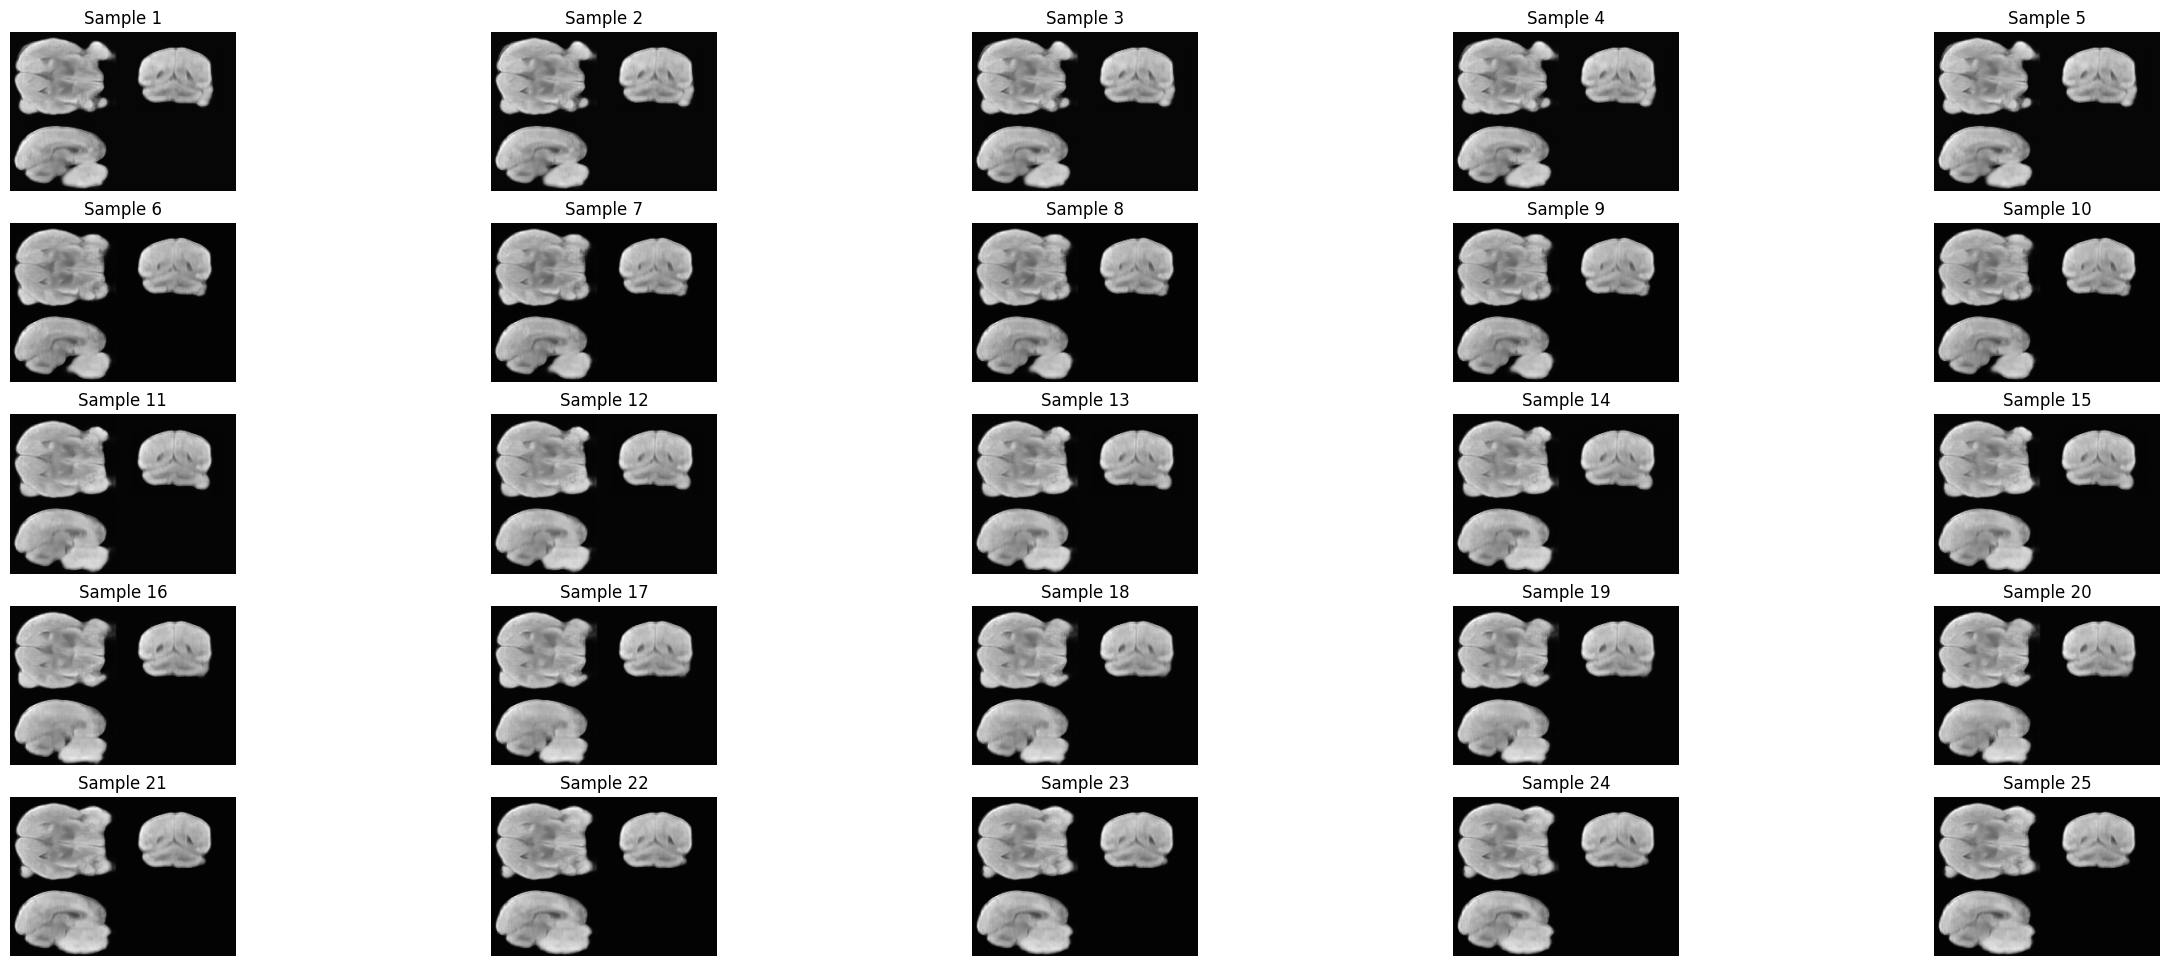

In [27]:
fig, ax = plt.subplots(nrows=5, ncols=5)
plt.style.use("default")
fig.set_size_inches(30, 12)
ii = 0
for i in range(5):
    for j in range(5):
        plotting_image_0 = np.concatenate([samples_array[i, :, :, 40], np.pad(np.flipud(samples_array[i, :, 40, :].T), pad_width=16)], axis=1)
        plotting_image_1 = np.concatenate([np.flipud(samples_array[i, 60, :, :].T), np.zeros((80, 144))], axis=1)
        image = np.concatenate([plotting_image_0, plotting_image_1], axis=0)
        ax[i,j].imshow(image, cmap="gray")
        ax[i,j].axis("off")
        ax[i,j].title.set_text("Sample " + str(ii + 1))
        ii += 1
plt.show()

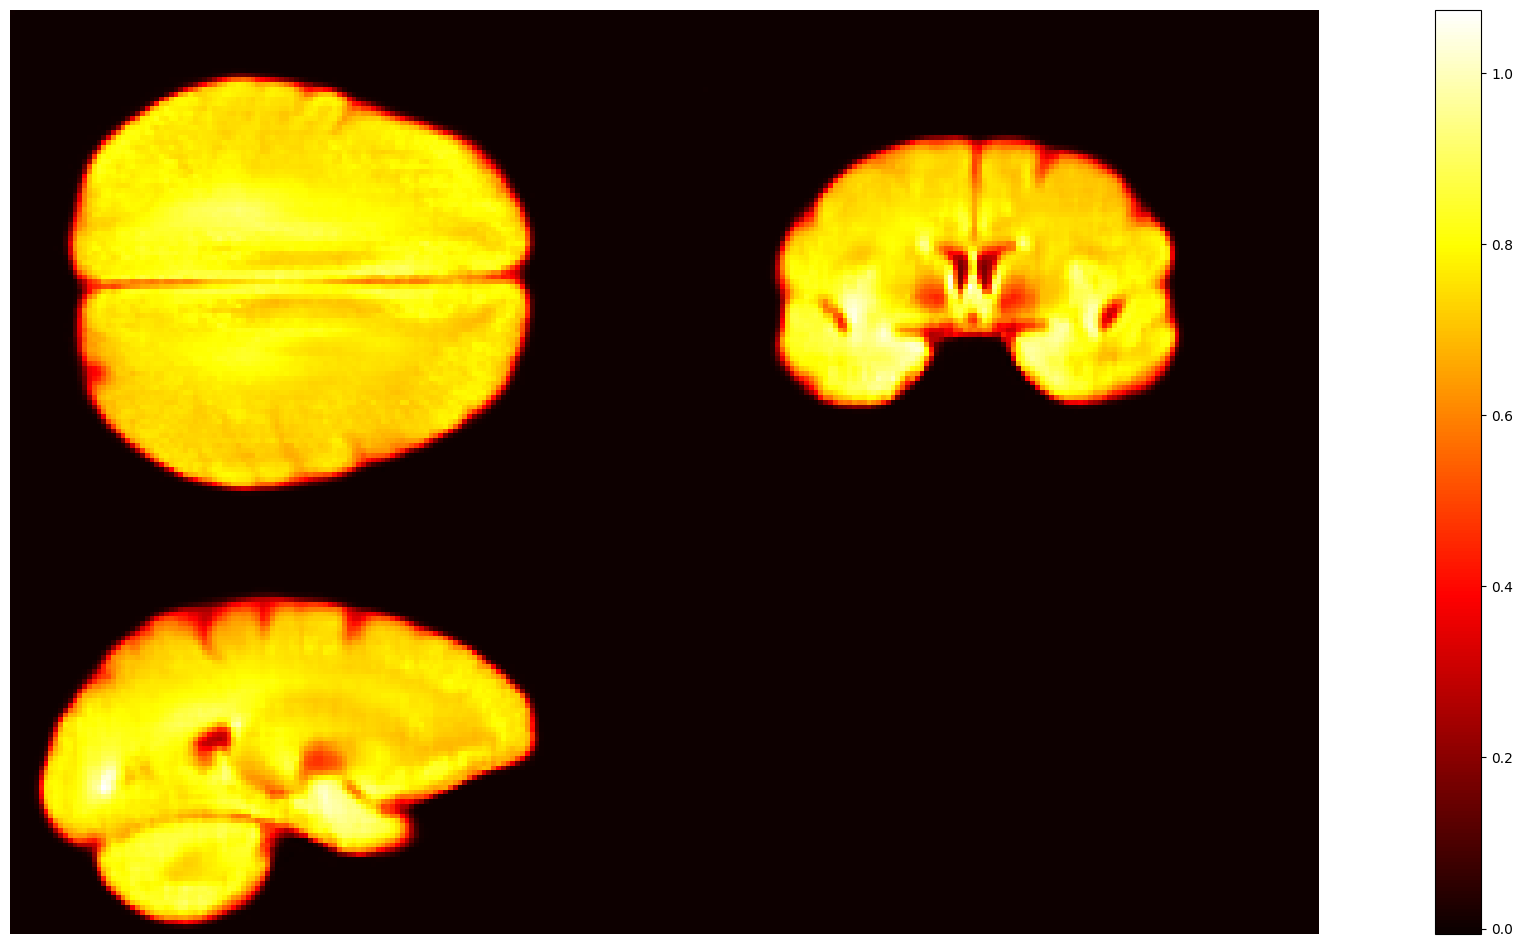

In [17]:
fig, ax = plt.subplots(nrows=1, ncols=1)
plt.style.use("default")
fig.set_size_inches(30, 12)

plotting_image_0 = np.concatenate([samples_heat[:, :, 50], np.pad(np.flipud(samples_heat[:, 70, :].T), pad_width=16)], axis=1)
plotting_image_1 = np.concatenate([np.flipud(samples_heat[70, :, :].T), np.zeros((80, 144))], axis=1)
image = np.concatenate([plotting_image_0, plotting_image_1], axis=0)
cax = ax.imshow(image, cmap="hot")
plt.colorbar(cax)
ax.axis("off")
plt.show()

### Save samples

In [13]:
from __future__ import annotations

import nibabel as nib

class NiftiSaver:
    def __init__(self, output_dir: str) -> None:
        super().__init__()
        self.output_dir = output_dir
        self.affine = np.array(
            [
                [-1., 0.0, 0.0, 96.48149872],
                [0.0, 1., 0.0, -141.47715759],
                [0.0, 0.0, 1., -156.55375671],
                [0.0, 0.0, 0.0, 1.0],
            ]
        )

    def save(self, image_data: torch.Tensor, file_name: str) -> None:
        image_data = image_data.cpu().numpy()
        image_data = image_data[0, 0, :, :, :]
        image_data = (image_data - image_data.min()) / (image_data.max() - image_data.min())
        image_data = (image_data * 255).astype(np.uint8)

        empty_header = nib.Nifti1Header()
        sample_nii = nib.Nifti1Image(image_data, self.affine, empty_header)
        nib.save(sample_nii, f"{str(self.output_dir)}/{file_name}.nii.gz")

In [21]:
saver = NiftiSaver(output_dir='./output')
for i, sample in enumerate(samples):
    outfile = datetime.now().strftime('sample_%H%M%S_%d%m%Y') + '_{:04d}'.format(i)
    saver.save(sample, outfile)